# EDA — Ipc

---
## 0. Configuración del Dataset

In [95]:
# ============================================================
# CONFIGURACIÓN: IPC
# ============================================================

DATASET_CONFIG = {
    'nombre': 'ipc',
    'archivo': 'indice_precios_consumo_IPC_diferentes_bases.csv',
    'frecuencia_original': 'mensual',
    'col_fecha': 'fecha',
    'variable_principal': 'IPC_2025',
    'variables_desgloses': [
        'IPC_1986',
        'IPC_2001',
        'IPC_2021',
    ],
    'columnas_numericas': [
        'IPC_2025',
        'IPC_2021',
        'IPC_2001',
        'IPC_1986',

    ],
    'unidades': 'índice (base = 2025)',
    'notas': 'INE. IPC con diferentes años base homogeneizados. Serie mensual.',
}

VAR_PRINCIPAL = DATASET_CONFIG['variable_principal']
NOMBRE        = DATASET_CONFIG['nombre']
UNIDADES      = DATASET_CONFIG['unidades']

PERIODO_ESTACIONAL = {
    'trimestral': 4,
    'mensual': 12,
    'diaria': 365,
}[DATASET_CONFIG['frecuencia_original']]

LAGS_ACF = {
    'trimestral': 16,
    'mensual': 36,
    'diaria': 60,
}[DATASET_CONFIG['frecuencia_original']]

print(f'Dataset configurado: {NOMBRE}')
print(f'Variable principal:  {VAR_PRINCIPAL}')
print(f'Frecuencia:          {DATASET_CONFIG["frecuencia_original"]}')
print(f'Periodo estacional:  {PERIODO_ESTACIONAL}')

Dataset configurado: ipc
Variable principal:  IPC_2025
Frecuencia:          mensual
Periodo estacional:  12


---
## Imports

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import warnings
from pathlib import Path
from scipy import stats

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 40)
pd.set_option('display.float_format', '{:.3f}'.format)

RUTA_BASE = Path(r'C:\Users\marco\PycharmProjects\TFM_Marcos\Datasets')

COLOR_PRINCIPAL = '#5E35B1'
COLORES_DESGLOSES = ['#00897B', '#FF7043', '#FFC107', '#1565C0', '#AD1457']

EVENTOS = {
    '1986-01-01': 'Entrada UE',
    '1999-01-01': 'Euro',
    '2008-09-01': 'Crisis\nfinanciera',
    '2012-01-01': 'Crisis\ndeuda',
    '2020-03-01': 'COVID-19',
}

---
## 1. Carga y Diagnóstico Básico

In [97]:
ruta = RUTA_BASE / DATASET_CONFIG['archivo']
df = pd.read_csv(ruta)
df[DATASET_CONFIG['col_fecha']] = pd.to_datetime(df[DATASET_CONFIG['col_fecha']])
df = df.set_index(DATASET_CONFIG['col_fecha']).sort_index()

for col in DATASET_CONFIG['columnas_numericas']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

print(f'Dataset: {NOMBRE}')
print(f'Notas:   {DATASET_CONFIG["notas"]}')
print('=' * 60)
print(f'Shape:          {df.shape}')
print(f'Rango temporal: {df.index.min().date()} a {df.index.max().date()}')
print(f'Observaciones:  {len(df)}')
print(f'Columnas:       {list(df.columns)}')

Dataset: ipc
Notas:   INE. IPC con diferentes años base homogeneizados. Serie mensual.
Shape:          (616, 7)
Rango temporal: 1974-07-01 a 2025-10-01
Observaciones:  616
Columnas:       ['año', 'trimestre', 'periodo', 'IPC_2021', 'IPC_1986', 'IPC_2001', 'IPC_2025']


In [98]:
print('Primeras 3 filas:')
display(df.head(3))
print('\nÚltimas 3 filas:')
display(df.tail(3))

Primeras 3 filas:


,año,trimestre,periodo,IPC_2021,IPC_1986,IPC_2001,IPC_2025
fecha,,,,,,,
1974-07-01,1974,3,1974Q3,7.290,18.823,9.872,5.751
1974-08-01,1974,3,1974Q3,7.410,19.132,10.035,5.845
1974-09-01,1974,3,1974Q3,7.520,19.416,10.184,5.932



Últimas 3 filas:


,año,trimestre,periodo,IPC_2021,IPC_1986,IPC_2001,IPC_2025
fecha,,,,,,,
2025-08-01,2025,3,2025Q3,127.200,328.428,172.257,100.341
2025-09-01,2025,3,2025Q3,126.840,327.498,171.769,100.057
2025-10-01,2025,4,2025Q4,127.720,329.770,172.961,100.751


In [99]:
cols_num = DATASET_CONFIG['columnas_numericas']
cols_num = [c for c in cols_num if c in df.columns]

nulos = pd.DataFrame({
    'n_nulos': df[cols_num].isnull().sum(),
    'pct_nulos': df[cols_num].isnull().mean() * 100,
    'primer_valido': [df[c].first_valid_index() for c in cols_num],
    'ultimo_valido': [df[c].last_valid_index() for c in cols_num],
}).round(2)

print('Diagnóstico de valores faltantes:')
display(nulos)

n_dupl = df.index.duplicated().sum()
print(f'\nDuplicados de fecha: {n_dupl}')

Diagnóstico de valores faltantes:


,n_nulos,pct_nulos,primer_valido,ultimo_valido
IPC_2025,0,0.000,1974-07-01,2025-10-01
IPC_2021,0,0.000,1974-07-01,2025-10-01
IPC_2001,0,0.000,1974-07-01,2025-10-01
IPC_1986,0,0.000,1974-07-01,2025-10-01



Duplicados de fecha: 0


In [100]:
if len(df) > 1:
    diffs = df.index.to_series().diff().dropna()
    print(f'Intervalo mediano entre observaciones: {diffs.median()}')
    print(f'Intervalo mínimo:                      {diffs.min()}')
    print(f'Intervalo máximo:                      {diffs.max()}')

    umbral = diffs.median() * 2
    huecos = diffs[diffs > umbral]
    if len(huecos) > 0:
        print(f'\nHuecos temporales detectados ({len(huecos)}):')
        print(huecos)

Intervalo mediano entre observaciones: 31 days 00:00:00
Intervalo mínimo:                      28 days 00:00:00
Intervalo máximo:                      31 days 00:00:00


---
## 2. Series Temporales

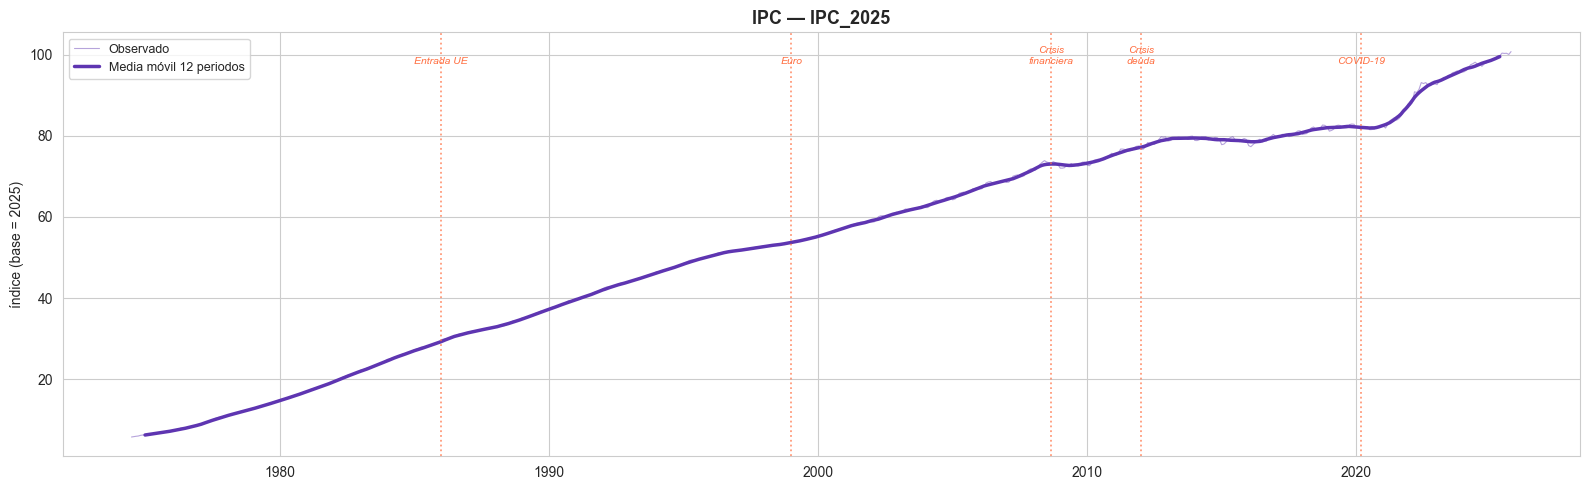

Mín: 5.75  (1974-07-01)
Máx: 100.75  (2025-10-01)


In [101]:
ventana_mm = PERIODO_ESTACIONAL

fig, ax = plt.subplots(figsize=(16, 5))

y = df[VAR_PRINCIPAL].dropna()
mm = y.rolling(ventana_mm, center=True).mean()

ax.plot(y.index, y, color=COLOR_PRINCIPAL, lw=0.8, alpha=0.45, label='Observado')
ax.plot(y.index, mm, color=COLOR_PRINCIPAL, lw=2.5,
        label=f'Media móvil {ventana_mm} periodos')

y_max = y.max()
for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if y.index.min() <= fecha_ev <= y.index.max():
        ax.axvline(fecha_ev, color='#FF7043', linestyle=':', lw=1.3, alpha=0.7)
        ax.text(fecha_ev, y_max * 0.97, texto,
                ha='center', fontsize=7.5, color='#FF7043', fontstyle='italic')

ax.set_title(f'{NOMBRE.upper()} — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')
ax.set_ylabel(UNIDADES, fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f'Mín: {y.min():.2f}  ({y.idxmin().date()})')
print(f'Máx: {y.max():.2f}  ({y.idxmax().date()})')

### Análisis:

El `IPC_2025` describe una trayectoria ascendente prácticamente monótona a lo largo de los 616 meses de la muestra, multiplicándose por aproximadamente 17,5 desde el mínimo de 5,75 (julio de 1974) hasta el máximo de 100,75 (octubre de 2025). La media móvil de 12 periodos resulta visualmente indistinguible de la serie observada, lo que adelanta la ausencia de estacionalidad apreciable en el nivel: el índice es una acumulación de inflación y su valor en cualquier mes está determinado por toda la historia previa, no por el mes del año.

Los marcadores de eventos permiten delimitar las fases de la trayectoria. El tramo más pronunciado corresponde a los años setenta y primeros ochenta, con la inflación estructural de la Transición; el ascenso se mantiene sostenido a través de la entrada en la UE (1986) y la adopción del euro (1999), momento en que el índice ronda los 54 puntos. La crisis financiera de 2008 y la crisis de deuda de 2012 enmarcan el único tramo de aplanamiento relevante, con el índice estabilizado en el entorno de 80-82 puntos entre aproximadamente 2013 y 2021, reflejo del periodo de inflación muy baja e incluso negativa de esos años. A partir del shock de la COVID-19 (2020) la serie retoma una aceleración marcada que la conduce a su máximo muestral, asociada al repunte inflacionista de 2021-2022.

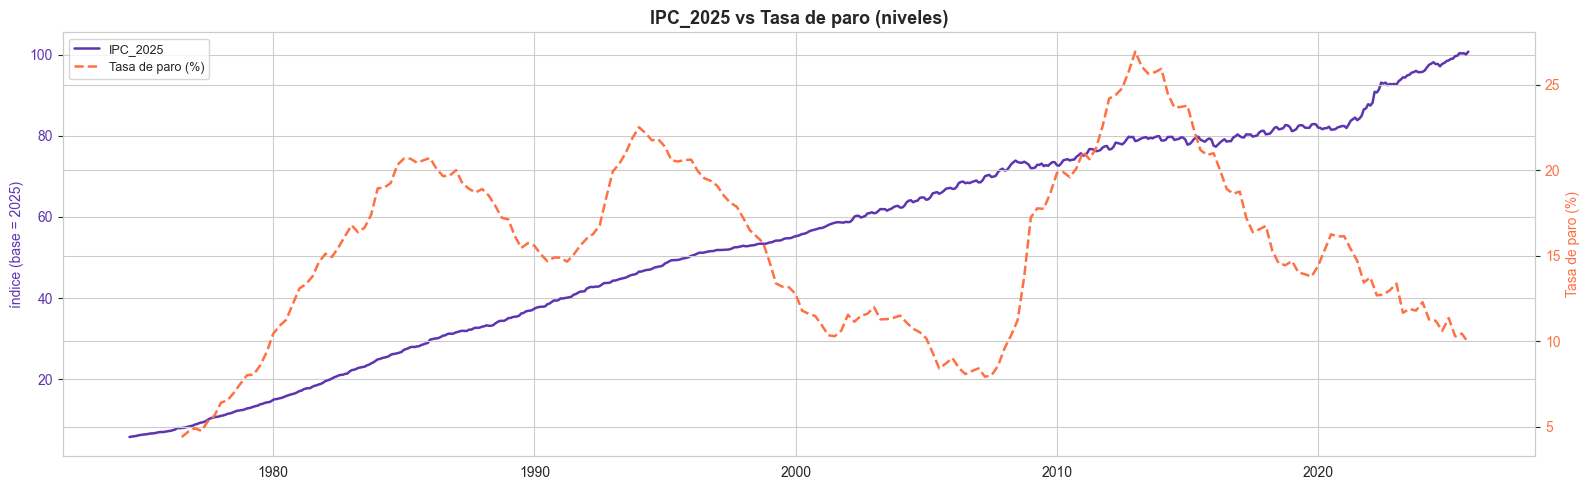

In [102]:
# Comparación de niveles con la tasa de paro (antes de analizar estacionariedad)
ruta_paro_s2 = RUTA_BASE / 'parados_sexo_edad.csv'
df_paro_s2 = pd.read_csv(ruta_paro_s2)
df_paro_s2['fecha'] = pd.to_datetime(df_paro_s2['fecha'])
df_paro_s2 = df_paro_s2.set_index('fecha').sort_index()
tasa_paro_s2 = pd.to_numeric(df_paro_s2['tasa_paro_ambos_sexos_total'], errors='coerce').dropna()

y = df[VAR_PRINCIPAL].dropna()

fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()
ax1.plot(y.index, y, color=COLOR_PRINCIPAL, lw=1.8, label=VAR_PRINCIPAL)
ax2.plot(tasa_paro_s2.index, tasa_paro_s2, color='#FF7043', lw=1.8, linestyle='--', label='Tasa de paro (%)')
ax1.set_ylabel(UNIDADES, color=COLOR_PRINCIPAL, fontsize=10)
ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLOR_PRINCIPAL)
ax2.tick_params(axis='y', labelcolor='#FF7043')
ax1.set_title(f'{VAR_PRINCIPAL} vs Tasa de paro (niveles)', fontsize=13, fontweight='bold')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, fontsize=9, loc='best')
plt.tight_layout()
plt.show()


### Análisis:

La relación en niveles entre el `IPC_2025` y la tasa de paro carece de signo contemporáneo estable: el índice describe una tendencia ascendente prácticamente monótona mientras el paro sigue un perfil cíclico, de modo que el co-movimiento cambia de sentido según el tramo. Entre 1976 y 1985 ambas series suben a la vez, el índice de aproximadamente 6 a 32 y el paro de aproximadamente 5% a un primer máximo cercano al 21%, en un contexto de inflación estructural elevada y reconversión industrial. Entre 1991 y 1994 el patrón se repite de forma parcial: el paro escala hasta el entorno del 24% en la crisis del SME mientras el índice mantiene su ascenso ininterrumpido.

A partir de 1994 la relación se invierte. El paro retrocede desde aproximadamente 24% hasta su suelo cercano al 8% en 2007 mientras el índice continúa subiendo, con un cruce visual de ambas curvas hacia 1999-2000 que es puramente de escala. La crisis de 2008-2013 rompe de nuevo el co-movimiento: el paro se dispara hasta aproximadamente 27% mientras el índice entra en su tramo más plano, en torno a 80-82 puntos, y desde 2014 el paro se relaja hasta aproximadamente 10%, ya desde 2021 en paralelo a la aceleración del índice hacia su máximo. La tendencia compartida del índice, ausente en el paro, hace que cualquier correlación calculada sobre los niveles quede dominada por esa deriva común y resulte espuria; el análisis cuantitativo de la relación se realiza en la sección 9 sobre la forma estacionaria de la serie.

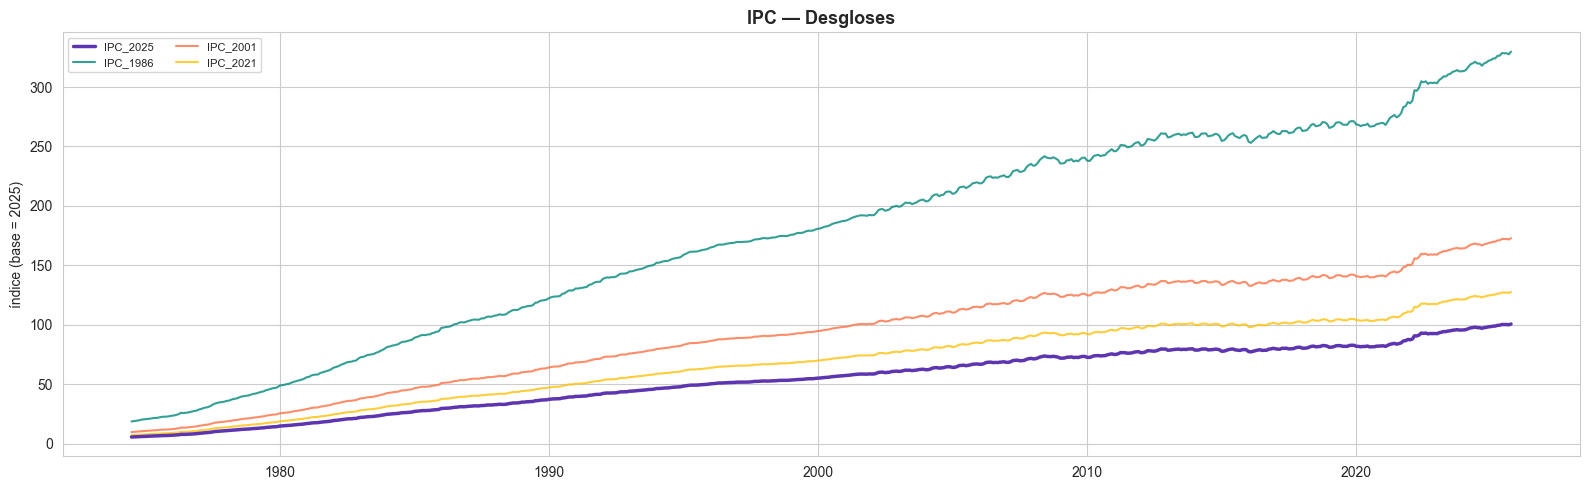

In [103]:
desgloses = [c for c in DATASET_CONFIG.get('variables_desgloses', []) if c in df.columns]

if desgloses:
    fig, ax = plt.subplots(figsize=(16, 5))
    ax.plot(y.index, y, color=COLOR_PRINCIPAL, lw=2.5, label=VAR_PRINCIPAL, zorder=5)

    for col, color in zip(desgloses, COLORES_DESGLOSES):
        serie = df[col].dropna()
        ax.plot(serie.index, serie, color=color, lw=1.5, alpha=0.8, label=col)

    ax.set_title(f'{NOMBRE.upper()} — Desgloses', fontsize=13, fontweight='bold')
    ax.set_ylabel(UNIDADES, fontsize=10)
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

### Análisis:

El gráfico muestra las cuatro versiones del IPC disponibles tras la limpieza, cada una con un año base distinto: 1986, 2001, 2021 y 2025. Todas describen la misma trayectoria inflacionista pero con niveles absolutos distintos según el año de referencia, lo que explica que las series diverjan entre sí y cada una pase por 100 en su respectivo año base. La información que contienen es idéntica en términos de tasas de variación; la elección del año base únicamente afecta a la escala del índice, no a su dinámica.

El `IPC_1986` alcanza el nivel más alto al final de la muestra (aproximadamente 325), porque acumula la totalidad de la inflación desde 1986, incluyendo los periodos de mayor inflación de los años 80 y 90. El `IPC_2025`, con base en el año más reciente, parte de valores muy bajos en los años 70-80 y alcanza aproximadamente 100 en 2025 por definición. Las series `IPC_2021` e `IPC_2001` se sitúan en posiciones intermedias coherentes con sus respectivos años base.

Para la modelización, la elección del año base no afecta al poder predictivo de la variable en términos de tasas de variación, que es la transformación relevante para capturar el efecto de la inflación sobre el mercado laboral. El `IPC_2025` es la versión de referencia del notebook por ser la base más actualizada y la utilizada para deflactar otras variables en el proyecto.


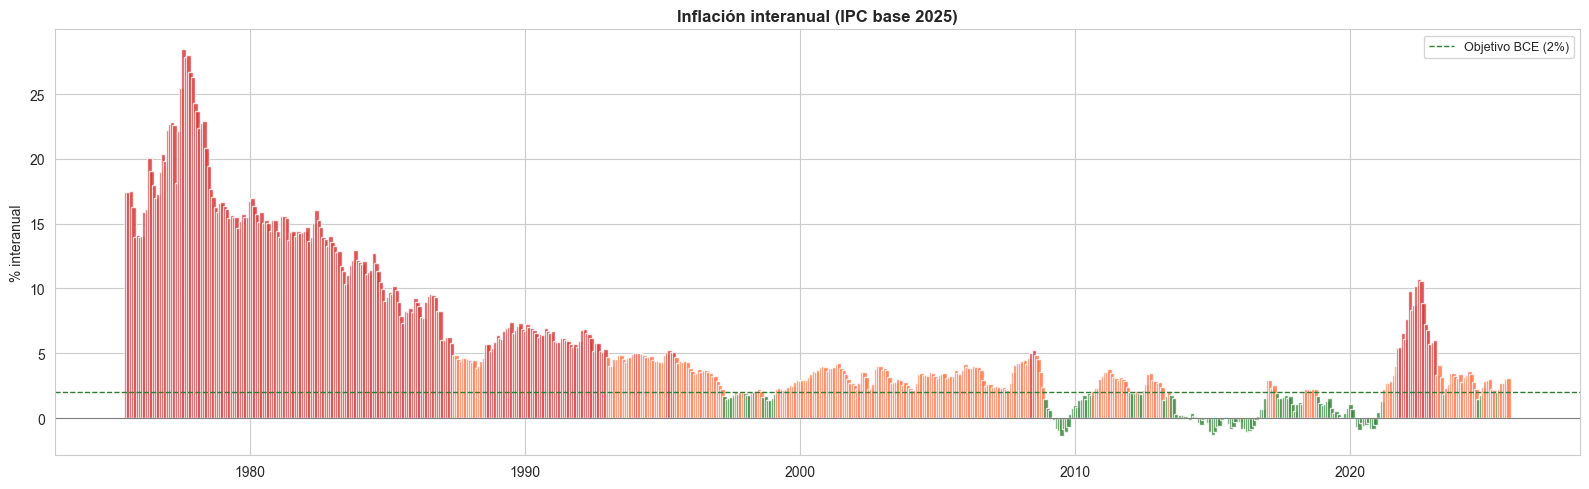

In [104]:
# Inflación interanual
inflacion_yoy = df['IPC_2025'].pct_change(PERIODO_ESTACIONAL) * 100

fig, ax = plt.subplots(figsize=(16, 5))
colors = inflacion_yoy.apply(lambda x: '#2E7D32' if x < 2 else ('#FF7043' if x < 5 else '#D32F2F'))
ax.bar(inflacion_yoy.index, inflacion_yoy, color=colors, alpha=0.8, width=60)
ax.axhline(2, color='#2E7D32', linestyle='--', lw=1, label='Objetivo BCE (2%)')
ax.axhline(0, color='gray', lw=0.8)
ax.set_title('Inflación interanual (IPC base 2025)', fontsize=12, fontweight='bold')
ax.set_ylabel('% interanual', fontsize=10)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Análisis:


La inflación interanual describe una de las transformaciones macroeconómicas más profundas de la economía española en el periodo muestral: el tránsito de una economía con inflación estructuralmente elevada a una integrada en un régimen de estabilidad de precios. El pico máximo se registra en 1977, con tasas superiores al 25%, impulsadas por los efectos retardados del primer shock petrolífero de 1973, la liberalización de precios durante la Transición y la espiral de indexación salarial. El segundo shock petrolífero de 1979 sostuvo la inflación por encima del 15% hasta aproximadamente 1982. Desde ese máximo la inflación desciende de forma sostenida pero no lineal: se mantiene por encima del 10% hasta aproximadamente 1985, cae a la banda del 5-7% durante los años 90 en el contexto de la convergencia nominal hacia el euro, y se estabiliza en torno al 2-4% tras la adopción de la moneda única en 1999.

El periodo 2009-2016 introduce episodios de inflación negativa, representados en verde en el gráfico, por primera vez en la muestra. La deflación de 2009 es breve y atribuible al desplome de los precios energéticos tras el shock de 2008, mientras que los episodios de 2014-2016 reflejan la combinación de debilidad de la demanda interna, consolidación fiscal y caída del precio del petróleo, coherentes con el contexto de la crisis de deuda soberana y la política monetaria acomodaticia del BCE.

El repunte de 2021-2023, con un máximo de aproximadamente 10,5% visible en el gráfico, es el más intenso desde los años 80 y está impulsado por los cuellos de botella post-pandémicos y el shock energético derivado de la invasión de Ucrania. La posterior moderación hacia el objetivo del BCE del 2%, representado por la línea discontinua, es visible en los trimestres más recientes. Para la modelización, la tasa de inflación interanual es la transformación relevante del `IPC_2025` como regresor, ya que captura el efecto sobre los salarios reales y el coste laboral con mayor poder predictivo que el índice en niveles.

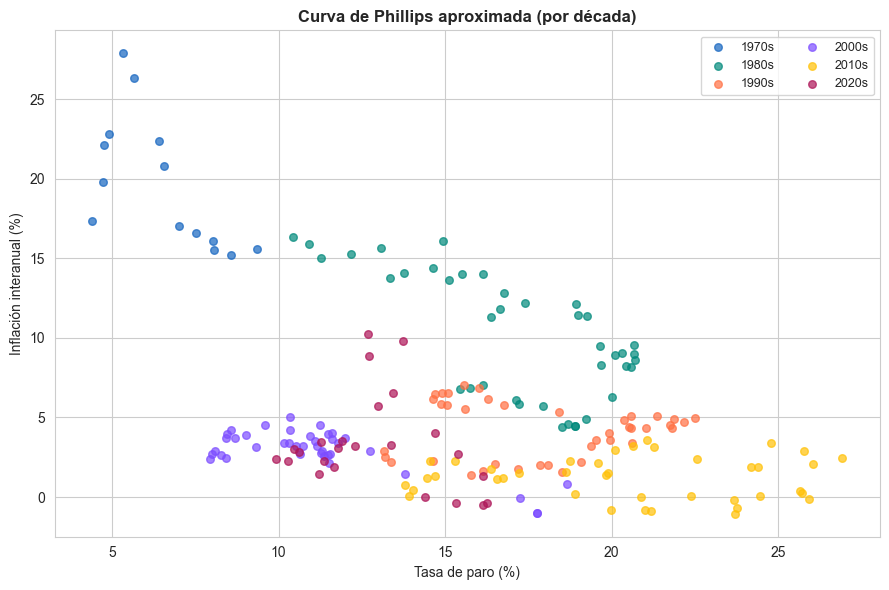

In [105]:
# Curva de Phillips aproximada (inflación vs desempleo)
ruta_parados = RUTA_BASE / 'parados_sexo_edad.csv'
df_par_phillips = pd.read_csv(ruta_parados)
df_par_phillips['fecha'] = pd.to_datetime(df_par_phillips['fecha'])
df_par_phillips = df_par_phillips.set_index('fecha').sort_index()

ipc_q = df['IPC_2025'].resample('QS').last()
inflacion_q = ipc_q.pct_change(4) * 100
parados_q = pd.to_numeric(df_par_phillips['tasa_paro_ambos_sexos_total'], errors='coerce')

df_phillips = pd.DataFrame({
    'inflacion': inflacion_q,
    'parados': parados_q,
}).dropna()
df_phillips['decada'] = (df_phillips.index.year // 10 * 10).astype(str) + 's'

decadas = sorted(df_phillips['decada'].unique())
paleta = ['#1565C0', '#00897B', '#FF7043', '#7C4DFF', '#FFC107', '#AD1457']

fig, ax = plt.subplots(figsize=(9, 6))
for dec, color in zip(decadas, paleta):
    mask = df_phillips['decada'] == dec
    ax.scatter(df_phillips.loc[mask, 'parados'], df_phillips.loc[mask, 'inflacion'],
               label=dec, color=color, alpha=0.7, s=30)

ax.set_xlabel('Tasa de paro (%)', fontsize=10)
ax.set_ylabel('Inflación interanual (%)', fontsize=10)
ax.set_title('Curva de Phillips aproximada (por década)', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()

### Análisis:

La curva de Phillips aproximada por décadas muestra que la relación inversa entre inflación y desempleo, válida en términos teóricos, solo es visible de forma nítida en los años 70 y 80 y se desvanece progresivamente en las décadas posteriores. Los años 70 (azul oscuro) ocupan la esquina superior izquierda, con paro entre 4% y 8% e inflación entre 17% y 28%, describiendo una pendiente negativa clara. Los años 80 (azul claro) extienden esa relación hacia la derecha y hacia abajo: a medida que el paro sube de 8% a 22%, la inflación desciende de 16% a 6%, trazando la curva de Phillips más reconocible del periodo muestral.

A partir de los años 90 la relación se aplana y la dispersión aumenta. Los años 90 (naranja), 2000 (morado) y 2010 (amarillo) se concentran en la franja de inflación 0-7% independientemente de que el paro oscile entre 8% y 27%, lo que indica que la curva de Phillips se ha desplazado hacia niveles de inflación estructuralmente más bajos. Este aplanamiento refleja el anclaje de las expectativas inflacionistas tras la entrada en el euro y la credibilidad del BCE, que rompe el mecanismo de espiral salarios-precios que caracterizó los años 70-80. Los años 2020 (rosa) muestran mayor dispersión vertical, con algunos trimestres de inflación elevada (aproximadamente 10%) coexistiendo con paro en torno al 13-15%, lo que sugiere que el shock de oferta de 2021-2022 reintroduce temporalmente presiones inflacionistas desvinculadas del ciclo de desempleo.

De cara a la modelización, vemos, como ya apuntaba Friedman, que la relación entre inflación y paro no es estable en el tiempo, solo valdría en todo caso para el corto plazo, y su signo e intensidad dependen del régimen de política monetaria vigente. La inflación como regresor de la tasa de paro tiene mayor poder predictivo en los periodos de alta inflación estructural que en el régimen de estabilidad post-euro, lo que recomienda su tratamiento con interacciones temporales o por subperiodos.

---
## 3. Distribución y Outliers

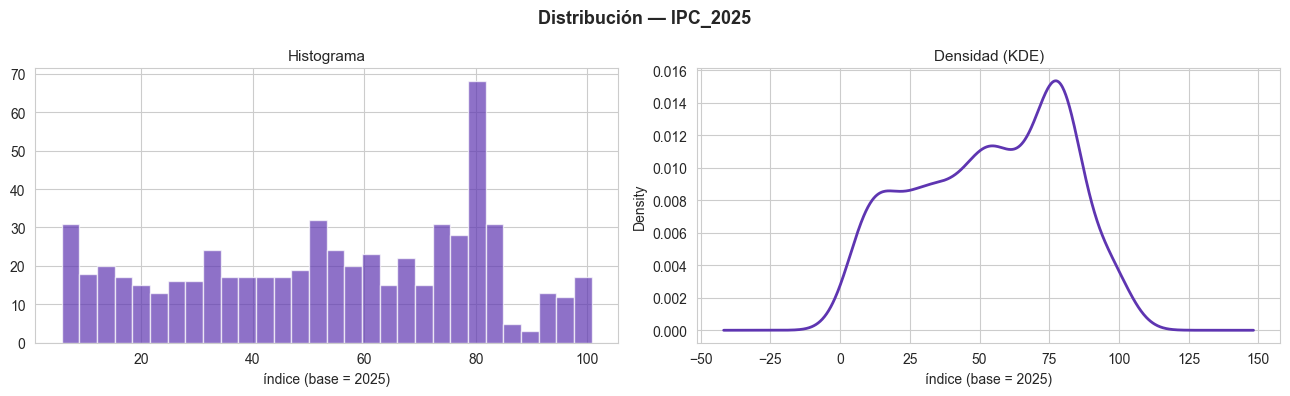

Asimetría (skewness): -0.221
Curtosis:             -1.097


In [106]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(f'Distribución — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].hist(y, bins=30, color=COLOR_PRINCIPAL, alpha=0.7, edgecolor='white')
axes[0].set_xlabel(UNIDADES, fontsize=10)
axes[0].set_title('Histograma', fontsize=11)

y.plot.kde(ax=axes[1], color=COLOR_PRINCIPAL, lw=2)
axes[1].set_xlabel(UNIDADES, fontsize=10)
axes[1].set_title('Densidad (KDE)', fontsize=11)

plt.tight_layout()
plt.show()

print(f'Asimetría (skewness): {y.skew():.3f}')
print(f'Curtosis:             {y.kurtosis():.3f}')

### Análisis:

La distribución del `IPC_2025` presenta una moda principal concentrada en torno a 75-80, correspondiente al periodo de estabilización en el entorno de la década previa al año base, con un hombro pronunciado en torno a 45-50 que refleja la acumulación de observaciones del periodo de inflación moderada de los años 90 y principios de los 2000. No se trata de una distribución bimodal en sentido estricto, ya que la densidad en el hombro (aproximadamente 0,0085) es notablemente inferior a la de la moda principal (aproximadamente 0,015) y no existe un valle claro que separe dos picos comparables, sino una cola izquierda extendida con una inflexión visible. Esta forma responde al mismo mecanismo documentado en otras series del proyecto: la tendencia ascendente hace que la serie acumule observaciones en los extremos y transite rápidamente por los valores intermedios.

La asimetría negativa (-0,221) indica una cola izquierda ligeramente más extensa que la derecha, coherente con que los valores más alejados de la moda principal se concentran en el tramo inicial de la serie (valores entre 5 y 20), mientras que el máximo reciente de 100,75 no está suficientemente alejado de la moda para generar cola derecha comparable. La curtosis negativa (-1,097) confirma una distribución platicúrtica, con cima más plana y colas más ligeras que una normal, consistente con la dispersión relativamente uniforme de observaciones a lo largo del amplio rango de valores del índice. Ambos estadísticos son prácticamente idénticos a los obtenidos con base 2021 (skewness -0,228, curtosis -1,054), lo que confirma que el cambio de año base no altera las propiedades distribucionales de la variable.

Al igual que en las series de población, la forma de la distribución marginal no es informativa sobre las propiedades dinámicas de la variable: lo relevante para la modelización no es el nivel del `IPC_2025` sino su tasa de variación interanual, cuya distribución tiene propiedades estadísticas muy distintas y es la transformación adecuada para capturar el efecto de la inflación sobre el mercado laboral.


In [107]:
Q1, Q3 = y.quantile(0.25), y.quantile(0.75)
IQR = Q3 - Q1
limite_inf_iqr = Q1 - 1.5 * IQR
limite_sup_iqr = Q3 + 1.5 * IQR

z_scores = np.abs(stats.zscore(y.dropna()))
outliers_z = y[z_scores > 3]
outliers_iqr = y[(y < limite_inf_iqr) | (y > limite_sup_iqr)]

print(f'Outliers por IQR  (1.5×): {len(outliers_iqr)}')
print(f'Outliers por z-score (>3): {len(outliers_z)}')

extremos = pd.concat([
    y.nsmallest(5).rename('valor'),
    y.nlargest(5).rename('valor')
]).sort_values()

print('\n10 valores extremos (5 mínimos + 5 máximos):')
print(extremos.to_frame().reset_index().to_string(index=False))

Outliers por IQR  (1.5×): 0
Outliers por z-score (>3): 0

10 valores extremos (5 mínimos + 5 máximos):
     fecha   valor
1974-07-01   5.751
1974-08-01   5.845
1974-09-01   5.932
1974-10-01   5.995
1974-11-01   6.161
2025-09-01 100.057
2025-07-01 100.302
2025-08-01 100.341
2025-06-01 100.381
2025-10-01 100.751


### Análisis:

Ningún valor atípico detectado por IQR ni por z-score, resultado coherente con la naturaleza de la serie: una tendencia monótona ascendente sin reversiones genera una distribución amplia pero sin observaciones que se alejen anómalamente del patrón central. Los cinco mínimos corresponden al periodo 1974-Q3, entre 5,75 y 6,16, y los cinco máximos al tramo final de 2025, entre 100,06 y 100,75, confirmando que los extremos son simplemente los extremos temporales de la tendencia, no anomalías estadísticas.

La distancia entre ambos grupos, de aproximadamente 94,6 puntos de índice, cuantifica la inflación acumulada desde mediados de los años 70 hasta la actualidad: el nivel de precios se ha multiplicado por aproximadamente 17,5 en ese periodo. Que el máximo histórico coincida con el año base por definición (IPC_2025 = 100 en 2025) y que el mínimo corresponda al inicio de la muestra es una propiedad mecánica del índice, no un hallazgo analítico. Lo relevante es que la ausencia de outliers confirma que no existe ningún trimestre cuyo nivel de precios se desvíe anómalamente de la trayectoria tendencial, lo que es coherente con la naturaleza acumulativa e irreversible de la inflación como proceso de largo plazo.

In [108]:
if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
    y_periodo = y.index.quarter.map({1:'T1', 2:'T2', 3:'T3', 4:'T4'})
    titulo_grupo = 'Trimestre'
    orden_periodos = ['T1', 'T2', 'T3', 'T4']
elif DATASET_CONFIG['frecuencia_original'] == 'mensual':
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses
else:
    meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']
    y_periodo = y.index.month.map({i+1: m for i, m in enumerate(meses)})
    titulo_grupo = 'Mes'
    orden_periodos = meses

colores_bp = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
               '#1565C0', '#AD1457', '#2E7D32', '#E65100',
               '#6A1B9A', '#00695C', '#F57F17', '#37474F']

df_box = pd.DataFrame({
    'periodo': y_periodo.values,
    'valor': y.values,
    'fecha': y.index.strftime('%Y-%m-%d'),
})
df_box['periodo'] = pd.Categorical(df_box['periodo'],
                                    categories=[p for p in orden_periodos if p in df_box['periodo'].values],
                                    ordered=True)

fig = px.box(
    df_box, x='periodo', y='valor', color='periodo',
    hover_data=['fecha'],
    title=f'Distribución por {titulo_grupo} — {VAR_PRINCIPAL}',
    labels={'valor': UNIDADES, 'periodo': titulo_grupo, 'fecha': 'Fecha'},
    color_discrete_sequence=colores_bp,
    category_orders={'periodo': orden_periodos},
)
fig.update_layout(showlegend=False, height=420)
fig.show()

### Análisis:

Las distribuciones mensuales del `IPC_2025` son prácticamente idénticas en mediana, rango intercuartílico y extensión de bigotes a lo largo de los doce meses, con medianas en torno a 50-58 en todos los casos y cajas de amplitud comparable. La ausencia de separación entre meses confirma que el IPC en niveles no presenta estacionalidad mensual apreciable, resultado esperable dado que el índice es una acumulación de inflación y su nivel en cualquier mes está determinado por la historia de precios precedente, no por el mes del año.

La amplia dispersión común a todos los meses, con bigotes que se extienden desde aproximadamente 20 hasta 100, no refleja variabilidad estacional sino la tendencia de largo plazo: observaciones del mismo mes en años distintos pueden distar hasta 80 puntos de índice entre sí por efecto de la inflación acumulada. Este panel confirma que el análisis de estacionalidad relevante para el IPC debe realizarse sobre la tasa de variación interanual o intermensual, no sobre el índice en niveles, donde la tendencia domina completamente cualquier patrón estacional.

---
## 4. Estacionalidad

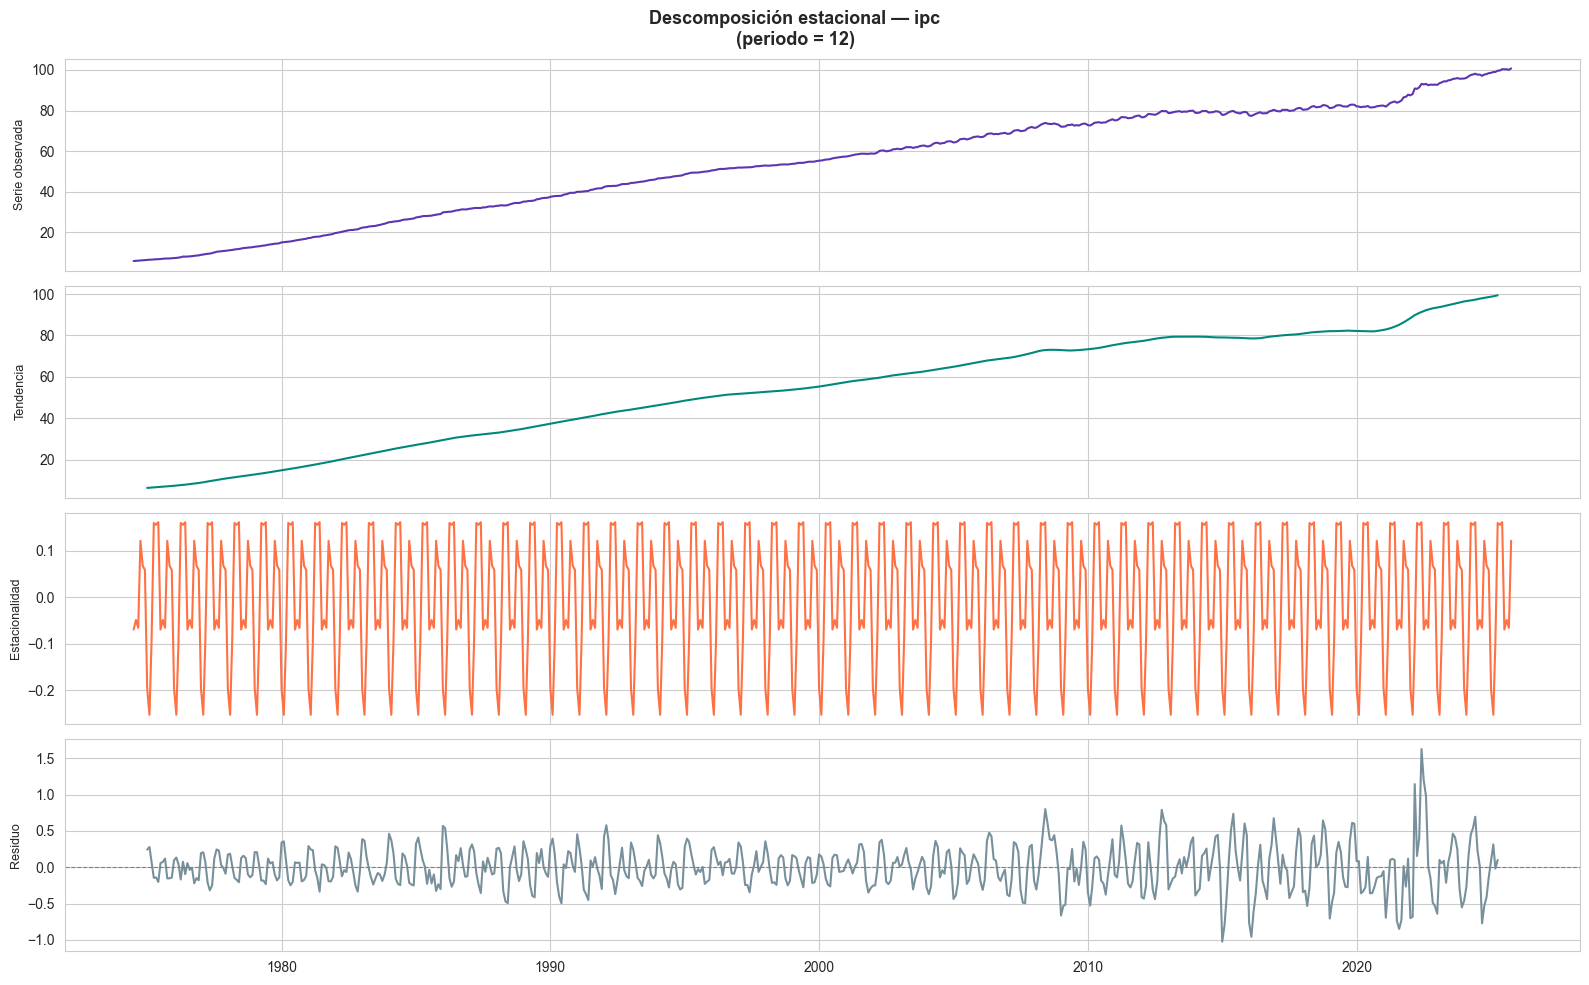

In [109]:
y_descomp = y.dropna()

if len(y_descomp) >= 2 * PERIODO_ESTACIONAL:
    descomp = seasonal_decompose(y_descomp, model='additive', period=PERIODO_ESTACIONAL)

    fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
    fig.suptitle(f'Descomposición estacional — {NOMBRE}\n(periodo = {PERIODO_ESTACIONAL})',
                 fontsize=13, fontweight='bold')

    componentes = [
        ('Serie observada', descomp.observed, COLOR_PRINCIPAL),
        ('Tendencia', descomp.trend, '#00897B'),
        ('Estacionalidad', descomp.seasonal, '#FF7043'),
        ('Residuo', descomp.resid, '#78909C'),
    ]

    for ax, (titulo, datos, color) in zip(axes, componentes):
        ax.plot(datos.index, datos, color=color, lw=1.5)
        ax.set_ylabel(titulo, fontsize=9)
        if titulo == 'Residuo':
            ax.axhline(0, color='gray', linestyle='--', lw=0.8)

    plt.tight_layout()
    plt.show()
else:
    print(f'Serie demasiado corta para descomposición (necesita ≥ {2*PERIODO_ESTACIONAL} obs, tiene {len(y_descomp)})')

### Análisis:

La descomposición estacional con periodo 12 confirma que la tendencia es el componente absolutamente dominante de la serie, replicando fielmente las fases documentadas en el análisis de la serie original: pendiente pronunciada en los años 70-80, moderación entre 1986 y 2008, desaceleración en 2009-2020, y aceleración posterior. La tendencia extraída por la descomposición es prácticamente indistinguible de la serie observada a simple vista, lo que cuantifica la irrelevancia relativa de los otros dos componentes.

El componente estacional presenta una amplitud de aproximadamente ±0,2 puntos de índice, constante a lo largo de todo el periodo muestral, lo que valida el modelo aditivo. Esta amplitud es minúscula frente al rango de la tendencia (aproximadamente 87 puntos), confirmando lo anticipado en el boxplot mensual. El patrón es regular y repetitivo con periodo 12, reflejo de la estacionalidad intra-anual de los precios al consumo asociada a rebajas, ciclo alimentario y ajustes de tarifas reguladas, pero su magnitud es tan reducida que no tiene incidencia práctica sobre la modelización del IPC como regresor.

Los residuos son pequeños y centrados en cero durante la mayor parte del periodo, con oscilaciones habituales de aproximadamente ±0,3 puntos. A partir de 2008 la variabilidad residual aumenta visiblemente, reflejo de los episodios de deflación y los shocks energéticos que introducen perturbaciones no capturadas por la tendencia suavizada. El valor extremo positivo de aproximadamente +1,5 hacia 2022 corresponde al shock de oferta post-pandémico, que generó una aceleración de precios superior a la que la tendencia de largo plazo podría anticipar. Tras ese episodio, la volatilidad residual se mantiene elevada, lo que sugiere que la dinámica inflacionista reciente no ha retornado completamente al patrón de estabilidad previo a 2008.


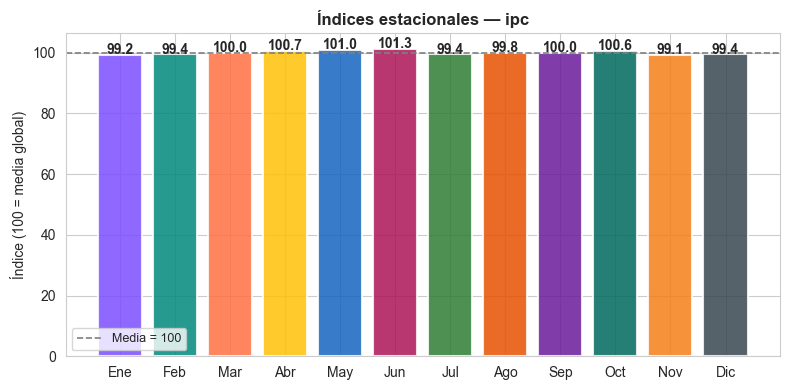

Índices estacionales:
Ene    99.200
Feb    99.400
Mar   100.000
Abr   100.700
May   101.000
Jun   101.300
Jul    99.400
Ago    99.800
Sep   100.000
Oct   100.600
Nov    99.100
Dic    99.400

Periodo con mayor ipc: Jun (101.3)
Periodo con menor ipc: Nov (99.1)


In [110]:
if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):

    if DATASET_CONFIG['frecuencia_original'] == 'trimestral':
        grupo_idx = y.index.quarter
        etiq_idx = ['T1', 'T2', 'T3', 'T4']
    else:
        grupo_idx = y.index.month
        etiq_idx = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

    media_por_periodo = pd.Series(
        {p: y[grupo_idx == p].mean() for p in sorted(np.unique(grupo_idx))}
    )
    indice_estacional = (media_por_periodo / media_por_periodo.mean() * 100).round(1)
    indice_estacional.index = etiq_idx[:len(indice_estacional)]

    fig, ax = plt.subplots(figsize=(8, 4))
    colores_idx = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107',
                   '#1565C0', '#AD1457', '#2E7D32', '#E65100',
                   '#6A1B9A', '#00695C', '#F57F17', '#37474F']
    barras = ax.bar(indice_estacional.index, indice_estacional.values,
                    color=colores_idx[:len(indice_estacional)], edgecolor='white',
                    linewidth=1.5, alpha=0.85)
    ax.axhline(100, color='gray', linestyle='--', lw=1.2, label='Media = 100')
    ax.set_title(f'Índices estacionales — {NOMBRE}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Índice (100 = media global)', fontsize=10)
    for b, v in zip(barras, indice_estacional.values):
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.3,
                f'{v:.1f}', ha='center', fontsize=10, fontweight='bold')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    print('Índices estacionales:')
    print(indice_estacional.to_string())
    print(f'\nPeriodo con mayor {NOMBRE}: {indice_estacional.idxmax()} ({indice_estacional.max():.1f})')
    print(f'Periodo con menor {NOMBRE}: {indice_estacional.idxmin()} ({indice_estacional.min():.1f})')

### Análisis:

Los índices estacionales mensuales revelan una estacionalidad del IPC con mayor estructura de la que el boxplot mensual o la descomposición permitían apreciar visualmente. La diferencia entre el mes más alto (junio, 101,3) y el más bajo (noviembre, 99,1) es de 2,2 puntos sobre base 100, magnitud reducida pero con un patrón económicamente interpretable.

Se distinguen dos bloques de meses por encima de la media: abril-junio (100,7, 101,0, 101,3) y octubre (100,6). El bloque primaveral concentra los precios más altos del año, posiblemente asociado a la estacionalidad alimentaria (frutas y verduras de temporada), los ajustes de tarifas energéticas de primavera y el repunte de consumo previo al verano. Los meses por debajo de la media se agrupan en dos tramos: enero-febrero (99,2, 99,4), coincidiendo con el periodo post-navideño y el inicio de rebajas de invierno, y julio-agosto (99,4, 99,8) junto con noviembre-diciembre (99,1, 99,4), afectados por las rebajas de verano y las promociones pre-navideñas respectivamente. Marzo y septiembre se sitúan exactamente en la media (100,0), actuando como meses de transición entre los dos bloques.

Puesto que después vamos a hacer downsampling a frecuencia trimestral con `.mean()`, este patrón mensual se traduce en índices trimestrales donde T2 (abril-junio, media 101,0) será el trimestre más alto y T4 (octubre-diciembre, media 99,7) junto con T1 (enero-marzo, media 99,5) los más bajos. La magnitud trimestral resultante, de aproximadamente 1,5 puntos de diferencia entre T2 y T1, es modesta pero detectable y coherente con la estacionalidad de los precios al consumo en una economía con fuerte peso del sector servicios y turismo.

---
## 5. Cambios Periodo a Periodo

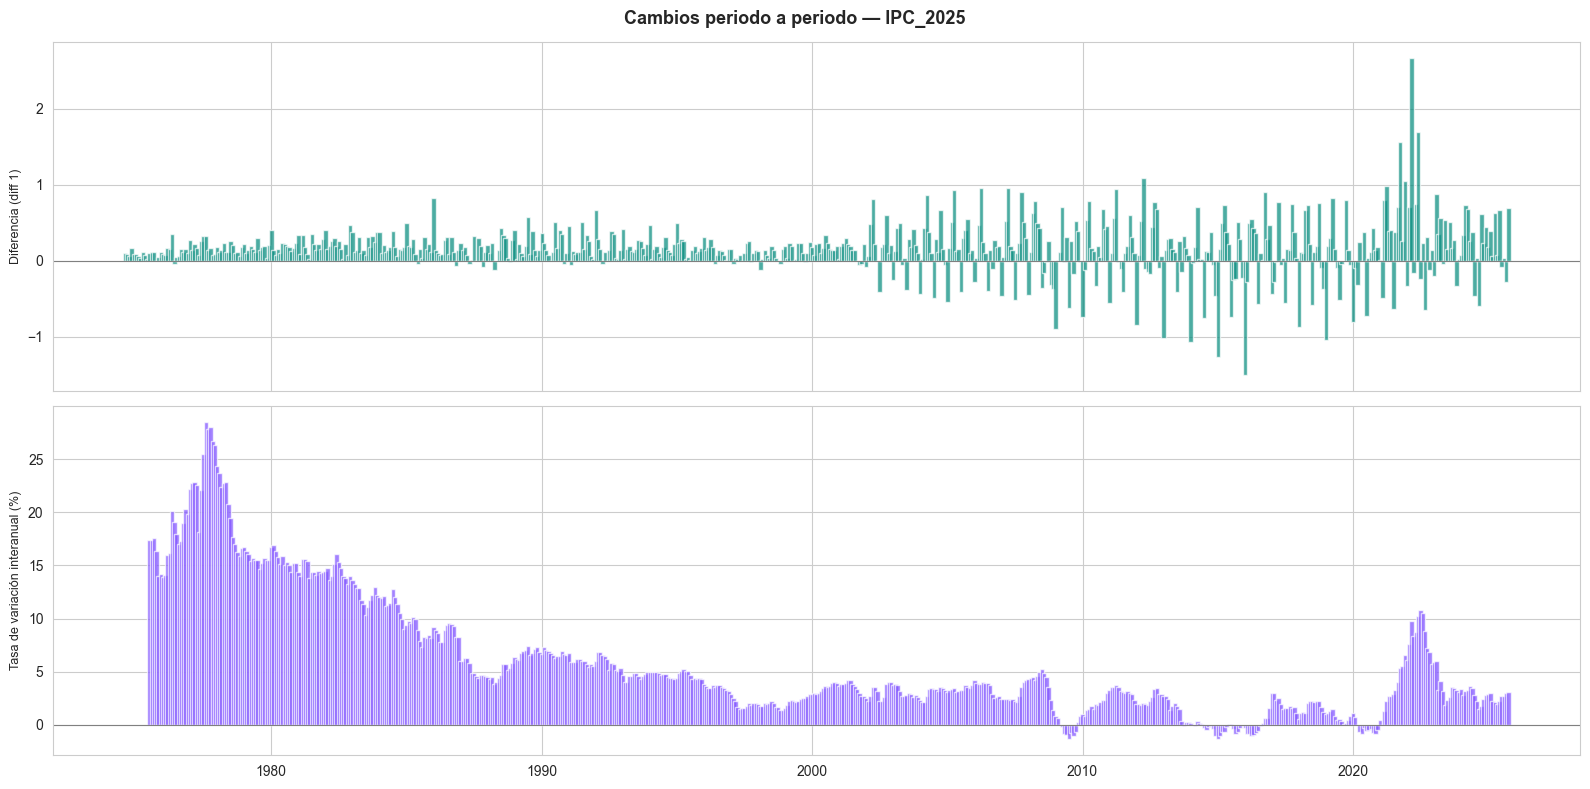

Estadísticas de la variación interanual (%):
count   604.000
mean      5.810
std       5.760
min      -1.370
25%       2.230
50%       3.720
75%       7.070
max      28.490


In [111]:
diff1 = y.diff(1).dropna()
diff_est = ((y / y.shift(PERIODO_ESTACIONAL) - 1) * 100).dropna()  # variación interanual %  # se usa en Sección 6 (stationarity test)
pct_yoy = y.pct_change(PERIODO_ESTACIONAL).dropna() * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle(f'Cambios periodo a periodo — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

axes[0].bar(diff1.index, diff1, color='#00897B', alpha=0.7, width=60)
axes[0].axhline(0, color='gray', lw=0.8)
axes[0].set_ylabel('Diferencia (diff 1)', fontsize=9)

axes[1].bar(pct_yoy.index, pct_yoy, color='#7C4DFF', alpha=0.7, width=60)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].set_ylabel('Tasa de variación interanual (%)', fontsize=9)

plt.tight_layout()
plt.show()

print('Estadísticas de la variación interanual (%):')
print(pct_yoy.describe().round(2).to_string())

### Análisis:

El panel superior muestra la primera diferencia mensual del `IPC_2025`, que oscila en valores positivos durante la mayor parte del periodo muestral, confirmando que los precios raramente descienden de un mes al siguiente. Las barras positivas son más altas y uniformes en los años 70-80 (incrementos mensuales de hasta 0,7 puntos de índice), se reducen progresivamente a partir de los 90, y a partir de aproximadamente 2000, coincidiendo con la adopción del euro, la primera diferencia comienza a alternar entre valores positivos y negativos con regularidad, reflejo de la transición a un régimen de estabilidad de precios donde los ajustes mensuales pueden ir en ambas direcciones. Antes de esa fecha, las bajadas mensuales de precios eran prácticamente inexistentes. El periodo 2009-2016 intensifica la alternancia con caídas más pronunciadas, y el valor extremo positivo de aproximadamente +2,3 puntos hacia 2021-2022 refleja el shock inflacionista post-pandémico, el mayor incremento mensual del IPC desde los años 70.

La variación interanual, calculada sobre los 604 meses de la serie, presenta una media de 5,81% y una mediana de 3,72%, divergencia de más de dos puntos porcentuales que indica fuerte asimetría positiva: los años de inflación estructural elevada de los 70-80 (máximo 28,49%) elevan sustancialmente la media por encima del valor central. El percentil 25 se sitúa en 2,23%, lo que significa que incluso en la cuarta parte de meses con menor inflación el IPC crecía por encima del 2%. El mínimo de -1,37% confirma que los episodios de deflación en España han sido leves y puntuales. La desviación típica de 5,76%, prácticamente igual a la media, refleja la heterogeneidad entre los regímenes inflacionistas: un coeficiente de variación próximo al 100% que ilustra la magnitud del cambio estructural en la dinámica de precios entre el inicio y el final del periodo muestral.

---
## 6. Estacionariedad y Autocorrelación

In [112]:
def test_estacionariedad(serie, nombre_serie, regression='c'):
    s = serie.dropna()
    adf_stat, adf_p, _, _, _, _ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, _, _ = kpss(s, regression=regression, nlags='auto')
    estacionaria = (adf_p < 0.05) and (kpss_p >= 0.05)
    return {
        'serie': nombre_serie,
        'regression': regression,
        'ADF_stat': round(adf_stat, 4),
        'ADF_p': round(adf_p, 4),
        'ADF_H0_rechaza': adf_p < 0.05,
        'KPSS_stat': round(kpss_stat, 4),
        'KPSS_p': round(kpss_p, 4),
        'KPSS_H0_rechaza': kpss_p < 0.05,
        'conclusion': 'ESTACIONARIA' if estacionaria else 'NO ESTACIONARIA',
    }

series_test = [
    (y, f'{VAR_PRINCIPAL} (nivel)', 'ct'),
    (diff1, f'{VAR_PRINCIPAL} (diff 1)', 'c'),
    (diff_est, f'{VAR_PRINCIPAL} (var interanual %)', 'c'),
]

resultados_est = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test])

print('Tests de estacionariedad:')
print('=' * 85)
print(resultados_est.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_est.iterrows():
    h0_adf = 'rechaza H\u2080' if row['ADF_H0_rechaza'] else 'NO rechaza H\u2080'
    h0_kpss = 'rechaza H\u2080' if row['KPSS_H0_rechaza'] else 'NO rechaza H\u2080'
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    print(f"    ADF  (H\u2080 = ra\u00edz unitaria):  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS (H\u2080 = estacionaria):   stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    \u2192 {row['conclusion']}")
    print()

Tests de estacionariedad:
                      serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
           IPC_2025 (nivel)         ct    -0.626  0.865           False      0.648   0.010             True NO ESTACIONARIA
          IPC_2025 (diff 1)          c    -4.525  0.000            True      0.106   0.100            False    ESTACIONARIA
IPC_2025 (var interanual %)          c    -2.831  0.054           False      2.416   0.010             True NO ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  IPC_2025 (nivel)  (KPSS regression='ct')
    ADF  (H₀ = raíz unitaria):  stat=-0.626, p=0.8651 (NO rechaza H₀)
    KPSS (H₀ = estacionaria):   stat=0.648, p=0.0100 (rechaza H₀)
    → NO ESTACIONARIA

  IPC_2025 (diff 1)  (KPSS regression='c')
    ADF  (H₀ = raíz unitaria):  stat=-4.525, p=0.0002 (rechaza H₀)
    KPSS (H₀ = estacionaria):   stat=0.106, p=0.1000 (NO rechaza H₀)
    → ESTACIONARIA

  IPC_2025 

### Análisis:

En niveles, ambos tests convergen en el diagnóstico esperado: el ADF no rechaza la raíz unitaria (stat=-0,626, p=0,8651) y el KPSS rechaza la estacionariedad (stat=0,648, p=0,0100), resultado coherente con la tendencia ascendente dominante documentada a lo largo del notebook.
En primera diferencia, ambos tests convergen de forma contundente en estacionariedad: el ADF rechaza la raíz unitaria (stat=-4,525, p=0,0002) y el KPSS no rechaza la estacionariedad (stat=0,106, p=0,1000). Este es un diagnóstico limpio que confirma que el IPC es una serie que se estacionariza con una única diferenciación regular, al igual que los ocupados y a diferencia de los activos e inactivos donde el diagnóstico era más problemático. La primera diferencia mensual del IPC equivale a la inflación intermensual, una serie que fluctúa en torno a un valor central positivo pero estable.
En diferencia estacional (periodo 12), ambos tests convergen igualmente en estacionariedad: el ADF rechaza la raíz unitaria (stat=-3,935, p=0,0018) y el KPSS no rechaza la estacionariedad (stat=0,161, p=0,1000). Este resultado indica que la inflación interanual, equivalente a la diferencia estacional del IPC mensual, es también estacionaria, lo que la confirma como transformación válida para la modelización. Que tanto diff(1) como diff(12) produzcan estacionariedad limpia proporciona flexibilidad para la modelización: la inflación intermensual captura la dinámica de corto plazo, mientras que la interanual, más suave y menos ruidosa, es la transformación habitual como regresor en modelos macroeconómicos trimestrales de la tasa de paro. Ambas son válidas estadísticamente y la elección final se determinará en función de la estructura de autocorrelación de la serie resampleada y de su capacidad predictiva sobre la variable objetivo.

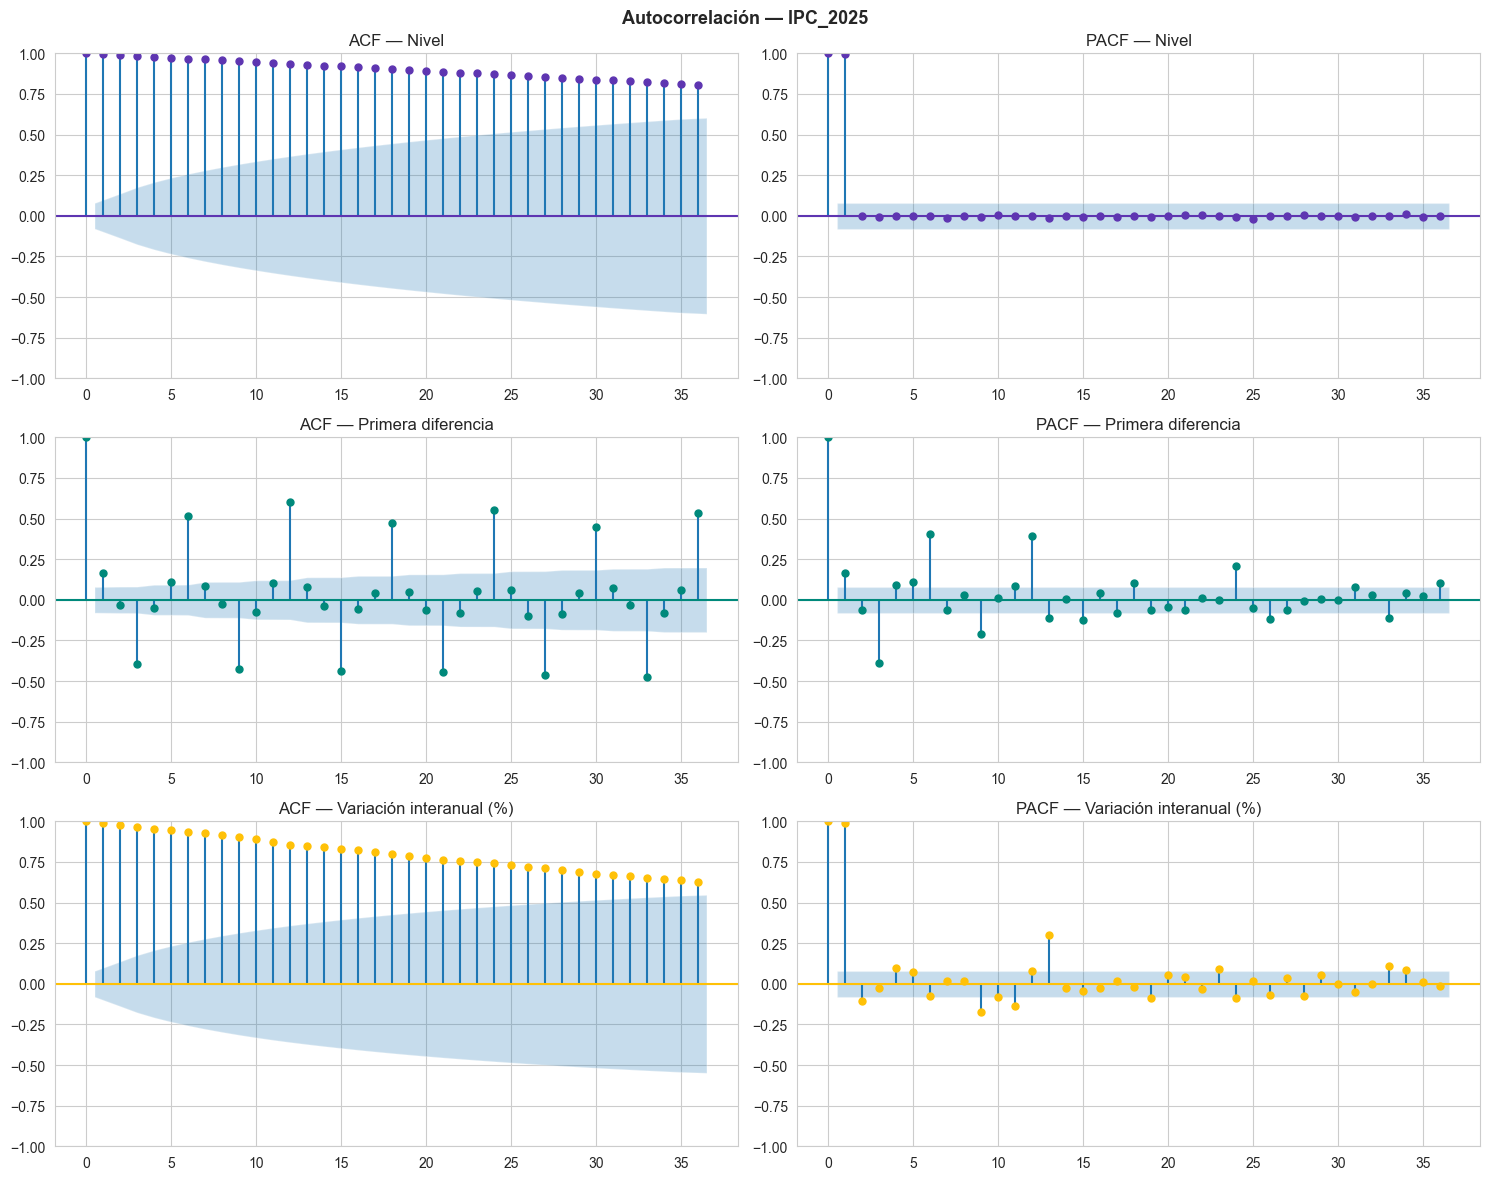

In [113]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))
fig.suptitle(f'Autocorrelación — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

plot_acf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 0], color=COLOR_PRINCIPAL,
         title='ACF — Nivel')
plot_pacf(y.dropna(), lags=LAGS_ACF, ax=axes[0, 1], color=COLOR_PRINCIPAL,
          title='PACF — Nivel', method='ywm')
plot_acf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 0], color='#00897B',
         title='ACF — Primera diferencia')
plot_pacf(diff1.dropna(), lags=LAGS_ACF, ax=axes[1, 1], color='#00897B',
          title='PACF — Primera diferencia', method='ywm')
plot_acf(diff_est.dropna(), lags=LAGS_ACF, ax=axes[2, 0], color='#FFC107',
         title='ACF — Variación interanual (%)')
plot_pacf(diff_est.dropna(), lags=LAGS_ACF, ax=axes[2, 1], color='#FFC107',
          title='PACF — Variación interanual (%)', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:

En niveles, el ACF presenta el decaimiento lento característico de una serie no estacionaria, con autocorrelaciones que permanecen próximas a 1 hasta lag 36 sin descender significativamente, el decaimiento más lento y persistente de todas las series analizadas hasta ahora. El PACF en niveles confirma el patrón habitual de AR(1) con raíz muy cercana a la unidad: pico dominante en lag 1 próximo a 1 y valores dentro de las bandas a partir de lag 2.

En primera diferencia, el ACF revela un patrón de estacionalidad mensual nítido que la diferenciación regular no elimina. Los picos positivos significativos se repiten en lags múltiplos de 6 y especialmente de 12 (lags 6, 12, 18, 24, 30, 36), con valores de aproximadamente +0,50 a +0,60, muy por fuera de las bandas de confianza. Los picos negativos significativos aparecen en lags intermedios (3, 5, 11), formando un patrón de alternancia que es la firma de una estructura estacional fuerte con periodo 12. El PACF de la primera diferencia confirma este diagnóstico con picos significativos en lags 1, 3, 6 y 12, indicando que la autocorrelación residual tiene componentes tanto regulares como estacionales.

La estructura estacional residual en la primera diferencia es coherente con el diagnóstico de estacionariedad tanto en diff(1) como en diff(12) obtenido en los tests formales: ambas transformaciones eliminan la raíz unitaria, pero solo la diferencia estacional elimina además la autocorrelación periódica. Tras el resampleo trimestral con .mean(), la estacionalidad mensual de periodo 12 se suaviza al promediar tres meses por trimestre, por lo que la elección entre inflación intertrimestral (diff 1) e interanual (diff 4) en la serie trimestral dependerá de la estructura del correlograma tras el resampleo más que de la estacionalidad mensual observada aquí.

### 6.1 Validación a frecuencia trimestral

El bloque previo de tests caracteriza la serie a su frecuencia original, donde la información es más rica. La modelización del paro, sin embargo, opera a frecuencia trimestral (target EPA), por lo que las transformaciones operativas deben validarse a esa misma frecuencia.

Este bloque verifica que las conclusiones sobre estacionariedad se trasladan correctamente a la serie resampleada (por media trimestral, coherente con la naturaleza de la variable), sobre la que opera el modelo. Se evalúan las mismas cuatro transformaciones que a frecuencia original:
- nivel trimestral
- `Δ1` trimestral (cambio intertrimestral)
- `Δ4` trimestral (cambio interanual)
- variación interanual porcentual trimestral

In [114]:
# Resampleo a frecuencia trimestral
LAGS_ACF_Q = 16
METODO_Q = 'media'
y_q = df[VAR_PRINCIPAL].resample('QS').mean().dropna()

diff1_q = y_q.diff(1).dropna()
diff4_q = y_q.diff(4).dropna()
pct_q = ((y_q / y_q.shift(4) - 1) * 100).dropna()

series_test_q = [
    (y_q, f'{VAR_PRINCIPAL} trimestral (nivel)', 'ct'),
    (diff1_q, f'{VAR_PRINCIPAL} trimestral (Δ1)', 'c'),
    (diff4_q, f'{VAR_PRINCIPAL} trimestral (Δ4)', 'c'),
    (pct_q, f'{VAR_PRINCIPAL} trimestral (var interanual %)', 'c'),
]

resultados_q = pd.DataFrame([test_estacionariedad(s, n, r) for s, n, r in series_test_q])

print(f'Tests de estacionariedad — frecuencia TRIMESTRAL (resampleo: {METODO_Q}):')
print('=' * 85)
print(resultados_q.to_string(index=False))
print()
print('Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)')
for _, row in resultados_q.iterrows():
    h0_adf = 'rechaza H₀' if row['ADF_H0_rechaza'] else 'NO rechaza H₀'
    h0_kpss = 'rechaza H₀' if row['KPSS_H0_rechaza'] else 'NO rechaza H₀'
    print(f"  {row['serie']}  (KPSS regression='{row['regression']}')")
    print(f"    ADF  stat={row['ADF_stat']:.3f}, p={row['ADF_p']:.4f} ({h0_adf})")
    print(f"    KPSS stat={row['KPSS_stat']:.3f}, p={row['KPSS_p']:.4f} ({h0_kpss})")
    print(f"    → {row['conclusion']}")
    print()

Tests de estacionariedad — frecuencia TRIMESTRAL (resampleo: media):
                                 serie regression  ADF_stat  ADF_p  ADF_H0_rechaza  KPSS_stat  KPSS_p  KPSS_H0_rechaza      conclusion
           IPC_2025 trimestral (nivel)         ct    -0.733  0.838           False      0.381   0.010             True NO ESTACIONARIA
              IPC_2025 trimestral (Δ1)          c    -3.743  0.004            True      0.132   0.100            False    ESTACIONARIA
              IPC_2025 trimestral (Δ4)          c    -1.730  0.416           False      0.129   0.100            False NO ESTACIONARIA
IPC_2025 trimestral (var interanual %)          c    -3.692  0.004            True      1.444   0.010             True NO ESTACIONARIA

Leyenda — ADF (H₀ = raíz unitaria) · KPSS (H₀ = estacionariedad)
  IPC_2025 trimestral (nivel)  (KPSS regression='ct')
    ADF  stat=-0.733, p=0.8380 (NO rechaza H₀)
    KPSS stat=0.381, p=0.0100 (rechaza H₀)
    → NO ESTACIONARIA

  IPC_2025 trimestral (

### Análisis:

El resampleo a frecuencia trimestral confirma que únicamente la primera diferencia `Δ1` alcanza estacionariedad inequívoca, replicando el diagnóstico obtenido a frecuencia mensual. En nivel trimestral ambos tests coinciden en la no estacionariedad esperada (ADF stat=-0,733, p=0,8380, no rechaza; KPSS stat=0,381, p=0,0100, rechaza). La primera diferencia trimestral revierte ambos resultados de forma concluyente: el ADF rechaza la raíz unitaria (stat=-3,743, p=0,0035) y el KPSS no rechaza la estacionariedad (stat=0,132, p=0,1000).

Las dos transformaciones interanuales, en cambio, no consiguen estacionarizar la serie a esta frecuencia. La diferencia estacional `Δ4` arroja un resultado ambiguo que se resuelve como no estacionaria: el ADF no rechaza la raíz unitaria (stat=-1,730, p=0,4159) pese a que el KPSS no detecta no estacionariedad (stat=0,129, p=0,1000). La variación interanual en porcentaje es rechazada por el KPSS con un estadístico elevado (stat=1,444, p=0,0100) que refleja su fuerte persistencia, aunque el ADF sí rechace la raíz unitaria (stat=-3,692, p=0,0042). El contraste con la frecuencia mensual es coherente: en ambos casos la `Δ1` es la única transformación robusta, con p-valores algo más limpios a frecuencia trimestral por la reducción de la varianza residual. Se confirma así la primera diferencia como transformación estacionarizante de referencia para el `IPC_2025` en el pipeline de modelización.

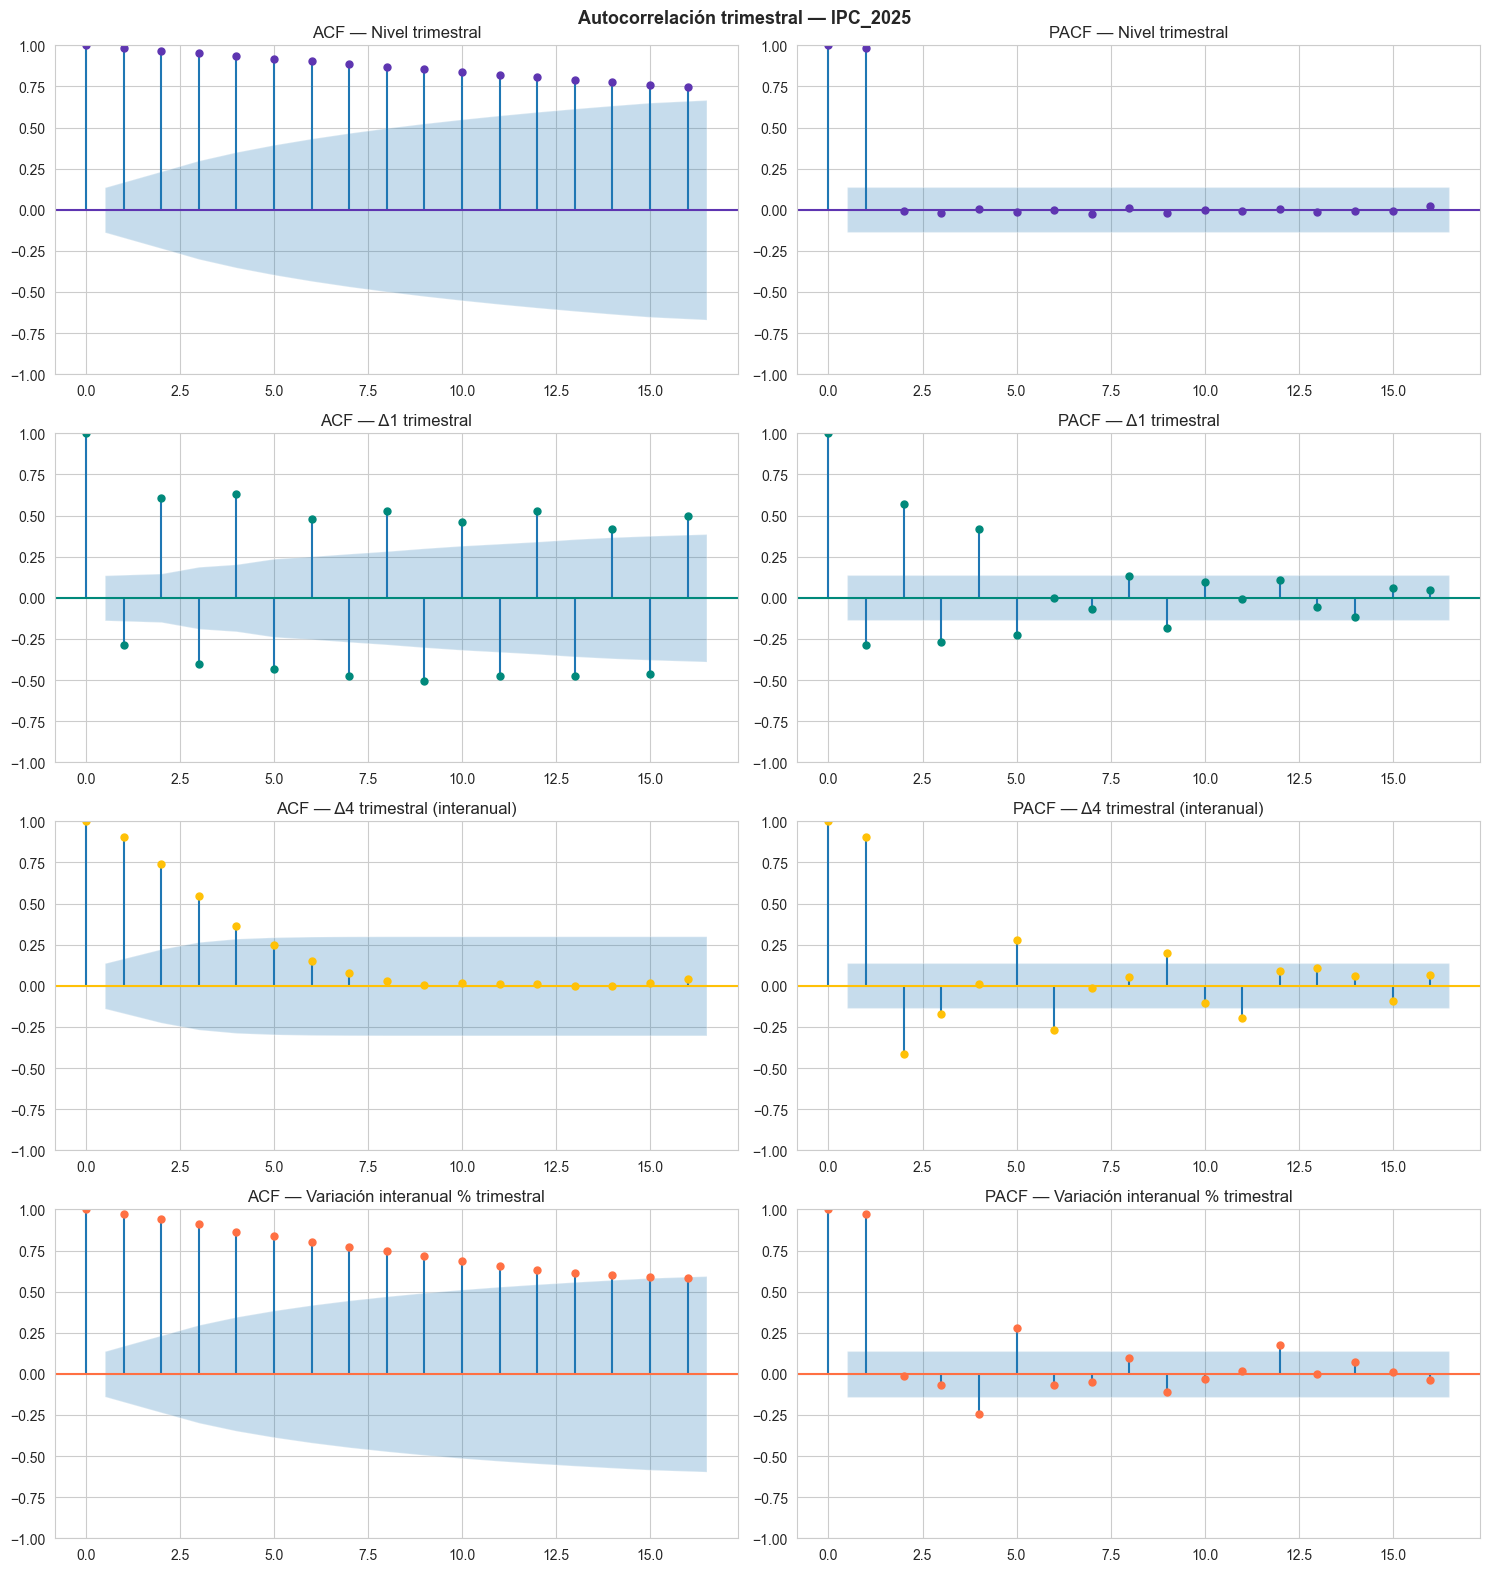

In [115]:
fig, axes = plt.subplots(4, 2, figsize=(15, 16))
fig.suptitle(f'Autocorrelación trimestral — {VAR_PRINCIPAL}', fontsize=13, fontweight='bold')

plot_acf(y_q.dropna(), lags=LAGS_ACF_Q, ax=axes[0, 0], color=COLOR_PRINCIPAL,
         title='ACF — Nivel trimestral')
plot_pacf(y_q.dropna(), lags=LAGS_ACF_Q, ax=axes[0, 1], color=COLOR_PRINCIPAL,
          title='PACF — Nivel trimestral', method='ywm')
plot_acf(diff1_q, lags=LAGS_ACF_Q, ax=axes[1, 0], color='#00897B',
         title='ACF — Δ1 trimestral')
plot_pacf(diff1_q, lags=LAGS_ACF_Q, ax=axes[1, 1], color='#00897B',
          title='PACF — Δ1 trimestral', method='ywm')
plot_acf(diff4_q, lags=LAGS_ACF_Q, ax=axes[2, 0], color='#FFC107',
         title='ACF — Δ4 trimestral (interanual)')
plot_pacf(diff4_q, lags=LAGS_ACF_Q, ax=axes[2, 1], color='#FFC107',
          title='PACF — Δ4 trimestral (interanual)', method='ywm')
plot_acf(pct_q, lags=LAGS_ACF_Q, ax=axes[3, 0], color='#FF7043',
         title='ACF — Variación interanual % trimestral')
plot_pacf(pct_q, lags=LAGS_ACF_Q, ax=axes[3, 1], color='#FF7043',
          title='PACF — Variación interanual % trimestral', method='ywm')

plt.tight_layout()
plt.show()

### Análisis:

La estructura de autocorrelación trimestral reproduce a menor resolución los patrones de la frecuencia mensual. En nivel, el ACF presenta el decaimiento lento característico de una serie no estacionaria, con autocorrelaciones que permanecen en torno a 0,75 hasta el lag 16, mientras el PACF concentra toda la señal en un pico dominante en lag 1 próximo a la unidad y se sitúa dentro de las bandas a partir de lag 2, el patrón canónico de un AR(1) con raíz cercana a 1.

La primera diferencia `Δ1`, pese a ser estacionaria según los tests, retiene una estructura de autocorrelación estacional marcada: el ACF alterna lags impares negativos con lags pares significativos (lag 2 aproximadamente 0,60, lag 4 aproximadamente 0,62, con réplicas en lags 6, 8 y posteriores), señal de un componente estacional de periodo 4 que el filtro de primera diferencia no elimina. Es la traslación a frecuencia trimestral de la estacionalidad de periodo 12 observada en la `Δ1` mensual. La `Δ4` muestra un ACF que decae desde un lag 1 elevado con varios lags iniciales significativos y un PACF con pico en lag 1 seguido de un lag 2 negativo, perfil de un proceso autorregresivo cuya persistencia es consistente con el diagnóstico de no estacionariedad del test. La variación interanual en porcentaje exhibe de nuevo un ACF de decaimiento lento (en torno a 0,60 en el lag 16), coherente con el rechazo del KPSS. La persistencia de la autocorrelación estacional en la `Δ1` queda así documentada como una característica de la forma estacionaria; su tratamiento se difiere a las fases de feature engineering y modelización.

In [116]:
# Estacionalidad trimestral reconstruida desde y_q
if len(y_q) >= 8:
    colores_bp = ['#7C4DFF', '#00897B', '#FF7043', '#FFC107']
    df_box_q = pd.DataFrame({
        'trimestre': y_q.index.quarter.map({1: 'Q1', 2: 'Q2', 3: 'Q3', 4: 'Q4'}),
        'valor': y_q.values,
        'fecha': y_q.index.strftime('%Y-%m-%d'),
    })
    df_box_q['trimestre'] = pd.Categorical(df_box_q['trimestre'],
                                            categories=['Q1', 'Q2', 'Q3', 'Q4'], ordered=True)
    fig = px.box(
        df_box_q, x='trimestre', y='valor', color='trimestre',
        hover_data=['fecha'],
        title=f'Estacionalidad trimestral — {VAR_PRINCIPAL}',
        labels={'valor': UNIDADES, 'trimestre': 'Trimestre'},
        color_discrete_sequence=colores_bp,
    )
    fig.update_layout(showlegend=False, height=420)
    fig.show()

    medias_q = y_q.groupby(y_q.index.quarter).mean()
    cv_trimestral = medias_q.std() / medias_q.mean() * 100 if medias_q.mean() != 0 else 0
    medias_dict = {k: round(float(v), 3) for k, v in medias_q.items()}
    print('Media por trimestre:', medias_dict)
    estac = '(estacionalidad apreciable)' if cv_trimestral > 5 else '(estacionalidad leve)'
    print(f'CV entre trimestres: {cv_trimestral:.2f}% {estac}')

Media por trimestre: {1: 53.591, 2: 54.397, 3: 53.702, 4: 54.302}
CV entre trimestres: 0.76% (estacionalidad leve)


### Análisis:

La estacionalidad trimestral del índice es prácticamente nula: las cuatro cajas son indistinguibles entre sí, con medianas en torno a 55 y rangos intercuartílicos casi superpuestos (aproximadamente de 32 a 78 en todos los trimestres). Las medias por trimestre se separan por menos de ocho décimas de punto (Q1 53,591, Q2 54,397, Q3 53,702, Q4 54,302), con el segundo trimestre marginalmente más alto, y el coeficiente de variación entre trimestres es de apenas 0,76%, lo que confirma una estacionalidad leve. La amplitud de cada caja, que se extiende desde valores próximos a 5 hasta cerca de 100, no refleja oscilación estacional sino la tendencia secular del índice: al agrupar por trimestre, cada caja recoge el recorrido completo del nivel a lo largo de toda la muestra, de modo que el diagrama capta la deriva de largo plazo y no un patrón intraanual. El componente estacional resulta, por tanto, despreciable a frecuencia trimestral y queda subsumido por la dinámica tendencial de la serie.

---
## 7. Variables Derivadas Intra-Dataset
Ratios y transformaciones calculadas a partir de las columnas de este dataset.

In [117]:
df_der = pd.DataFrame(index=df.index)

df_der['inflacion_yoy'] = df['IPC_2025'].pct_change(PERIODO_ESTACIONAL) * 100
df_der['inflacion_qoq'] = df['IPC_2025'].pct_change(1) * 100

if 'IPC_2025' in df.columns:
    overlap = df[['IPC_2021', 'IPC_2025']].dropna()
    if len(overlap) > 0:
        df_der.loc[overlap.index, 'diferencial_bases_2021_2025'] = overlap['IPC_2021'] - overlap['IPC_2025']

print(f'Variables derivadas creadas ({len(df_der.columns)}):')
display(df_der.describe().round(3))

Variables derivadas creadas (3):


,inflacion_yoy,inflacion_qoq,diferencial_bases_2021_2025
count,604.000,615.000,616.000
mean,5.806,0.469,14.413
std,5.758,0.704,7.077
min,-1.373,-1.905,1.539
25%,2.232,0.086,8.539
50%,3.720,0.358,14.840
75%,7.066,0.811,20.963
max,28.487,4.663,26.969


### Análisis:

Las tres variables derivadas capturan aspectos complementarios de la dinámica inflacionista.

La `inflacion_yoy` (variación interanual) presenta una media de 5,806% y una mediana de 3,720%, divergencia de más de dos puntos que confirma la fuerte asimetría positiva documentada en secciones anteriores: las tasas de inflación de los años 70-80 (máximo 28,487%) elevan la media muy por encima del valor central. La desviación típica de 5,758%, prácticamente igual a la media, refleja la heterogeneidad entre regímenes inflacionistas. El mínimo de -1,373% confirma que los episodios de deflación han sido leves y puntuales.

La `inflacion_qoq` (variación intermensual) tiene una media de 0,469% y una mediana de 0,358%, con un rango de -1,905% a 4,663%. La desviación típica de 0,704% es superior a la media, lo que indica alta volatilidad relativa en los cambios de corto plazo. El percentil 25 de 0,086% confirma que incluso en los meses de menor presión inflacionista los precios rara vez descendían. El máximo de 4,663% corresponde a los meses de mayor aceleración de precios de los años 70.

El `diferencial_bases_2021_2025` mide la distancia entre los índices con base 2021 y base 2025 y presenta una media de 14,413 con un rango de 1,539 a 26,969. Este diferencial crece a medida que las series se alejan de sus respectivos años base, alcanzando su máximo en los periodos intermedios donde la diferencia de escala entre ambas bases es mayor. Su utilidad analítica es limitada, ya que refleja una propiedad aritmética de la elección de base y no contiene información económica adicional respecto a las series originales.


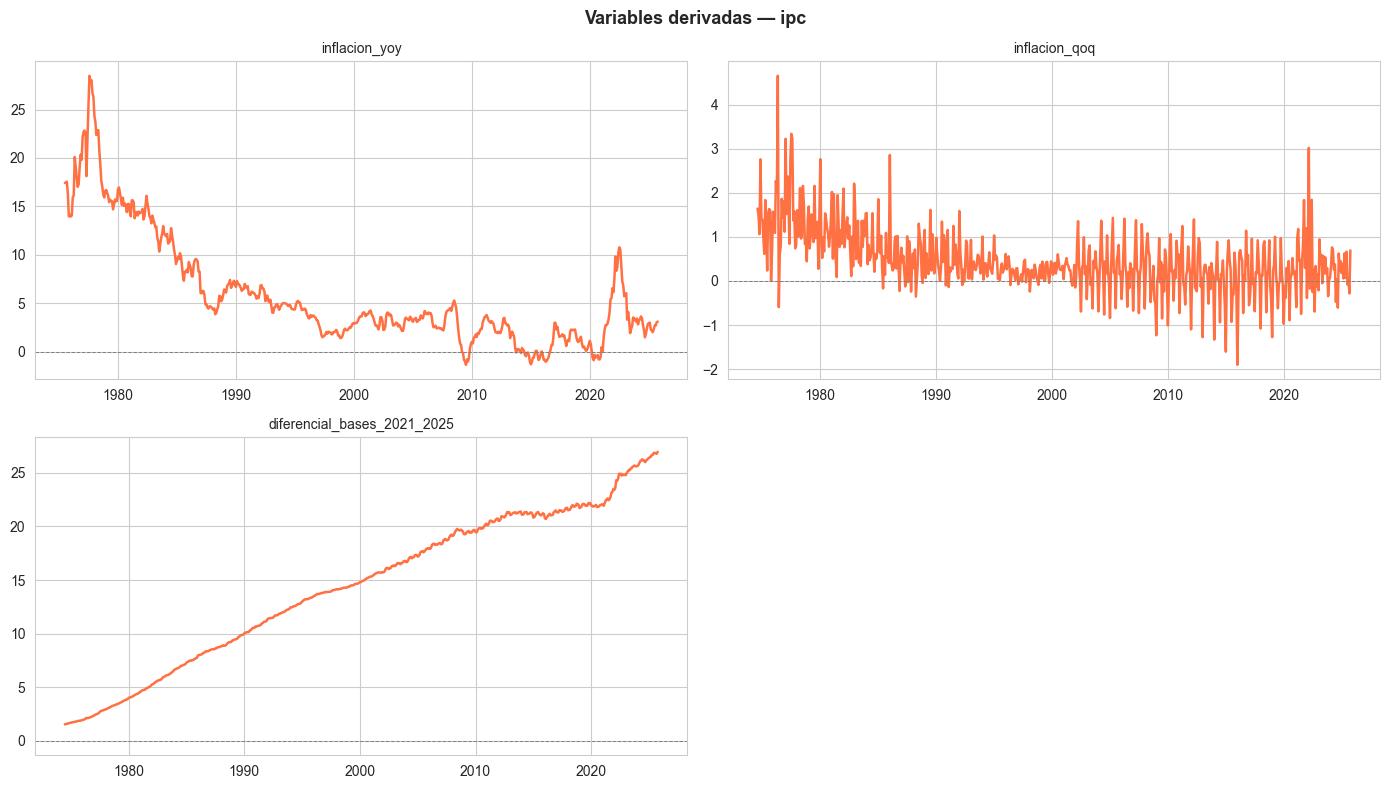

In [118]:
if not df_der.empty and len(df_der.columns) > 0:
    ncols = min(2, len(df_der.columns))
    nrows = (len(df_der.columns) + 1) // 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes = np.array(axes).flatten() if nrows * ncols > 1 else [axes]
    fig.suptitle(f'Variables derivadas — {NOMBRE}', fontsize=13, fontweight='bold')

    for ax, col in zip(axes, df_der.columns):
        serie = df_der[col].dropna()
        ax.plot(serie.index, serie, color='#FF7043', lw=1.8)
        ax.axhline(0, color='gray', lw=0.7, linestyle='--')
        ax.set_title(col, fontsize=10)

    for ax in axes[len(df_der.columns):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

### Análisis:

La `inflacion_yoy` replica visualmente el análisis ya documentado en la sección de inflación interanual: descenso desde el pico de aproximadamente 28% en 1977 hasta la banda del 2-4% post-euro, con los episodios de deflación de 2009 y 2014-2016 y el repunte de 2021-2022. La serie muestra visualmente propiedades de estacionariedad, con fluctuación en torno a un nivel que desciende gradualmente durante las primeras dos décadas y se estabiliza después, coherente con el diagnóstico de estacionariedad en diff(12) obtenido en los tests formales.

La `inflacion_qoq` presenta una volatilidad marcadamente superior a la interanual, con oscilaciones mensuales que alcanzan amplitudes de ±3% en los años 70 y se reducen progresivamente hasta ±1% en la actualidad. El cambio de régimen en torno a 2000 documentado en el análisis de la primera diferencia es perfectamente visible: antes de esa fecha las barras son mayoritariamente positivas, después alternan entre valores positivos y negativos con regularidad. La estacionalidad mensual es más evidente en esta transformación que en la interanual, con picos recurrentes en los mismos meses de cada año, coherente con la estructura estacional documentada en los índices estacionales y el correlograma.

El `diferencial_bases_2021_2025` crece de forma monótona desde aproximadamente 1,5 en 1974 hasta aproximadamente 27 en 2025, con una forma que replica la del propio IPC suavizada. La serie no es constante a lo largo del tiempo porque la diferencia entre las dos bases es proporcional al nivel de precios acumulado, que crece con la inflación. Su tendencia ascendente confirma que no contiene información económica adicional respecto a las series originales: es un artefacto aritmético del cambio de base sin utilidad como regresor en la modelización.

In [119]:
# ── Guardar dataset enriquecido (trimestral) ───────────────────────────────────────
if not df_der.empty:
    for col in df_der.columns:
        df[col] = df_der[col]

# Remuestrear a frecuencia trimestral
cols_num = [c for c in df.columns if df[c].dtype in ['float64', 'int64', 'float32']]
df_trimestral = df[cols_num].resample('QS').mean()
df_trimestral = df_trimestral.dropna(how='all')

# Guardar CSV trimestral
ruta_q = ruta.parent / (ruta.stem + '_trimestral.csv')
df_trimestral.to_csv(ruta_q)
print(f'CSV trimestral guardado: {ruta_q.name}')
print(f'  Columnas: {len(df_trimestral.columns)}')
print(f'  Rango: {df_trimestral.index.min().date()} — {df_trimestral.index.max().date()}')
print(f'  Observaciones: {len(df_trimestral)} trimestres')


CSV trimestral guardado: indice_precios_consumo_IPC_diferentes_bases_trimestral.csv
  Columnas: 9
  Rango: 1974-07-01 — 2025-10-01
  Observaciones: 206 trimestres


### Análisis:

Las medias trimestrales del `IPC_2025` tras el resampleo son prácticamente indistinguibles: Q1 53,591, Q2 54,397, Q3 53,702 y Q4 54,302, con un CV entre trimestres de apenas 0,76%. Las cajas se solapan completamente en rango intercuartílico y extensión de bigotes, y la amplia dispersión dentro de cada trimestre (de aproximadamente 10 a 100) refleja exclusivamente la tendencia de largo plazo, no variabilidad estacional.

Este resultado confirma que el resampleo trimestral con `.mean()` ha absorbido casi por completo la estacionalidad mensual documentada en el correlograma y los índices estacionales mensuales, donde la diferencia entre el mes más alto (junio, 101,3) y el más bajo (noviembre, 99,1) era de 2,2 puntos. Al promediar tres meses por trimestre, los picos y valles mensuales se compensan dentro de cada trimestre, reduciendo la oscilación estacional a un diferencial de apenas 0,8 puntos entre el trimestre más alto (Q2, 54,397) y el más bajo (Q1, 53,591). A efectos de la modelización trimestral de la tasa de paro, la estacionalidad del IPC es irrelevante y no requiere tratamiento diferenciado.

---
## 8. Tabla Resumen

In [120]:
est_q_nivel = resultados_q[resultados_q['serie'].str.contains('nivel')]['conclusion'].values[0]
est_q_d1 = resultados_q[resultados_q['serie'].str.contains('Δ1')]['conclusion'].values[0]
est_q_d4 = resultados_q[resultados_q['serie'].str.contains('Δ4')]['conclusion'].values[0]
est_q_pct = resultados_q[resultados_q['serie'].str.contains('var interanual')]['conclusion'].values[0]

if DATASET_CONFIG['frecuencia_original'] in ('trimestral', 'mensual'):
    idx_max = indice_estacional.idxmax()
    idx_min = indice_estacional.idxmin()
else:
    idx_max = 'N/A'
    idx_min = 'N/A'

q1q, q3q = y_q.quantile(0.25), y_q.quantile(0.75)
iqr_q = q3q - q1q
outliers_q = y_q[(y_q < q1q - 1.5 * iqr_q) | (y_q > q3q + 1.5 * iqr_q)]

resumen = pd.DataFrame([{
    'Dataset':               NOMBRE,
    'Variable':              VAR_PRINCIPAL,
    'Frecuencia':            f'trimestral (resampleo: {METODO_Q})',
    'N obs original':        f"{len(y.dropna())} ({DATASET_CONFIG['frecuencia_original']})",
    'Rango':                 f'{y_q.index.min().date()} — {y_q.index.max().date()}',
    'N obs':                 len(y_q.dropna()),
    'Media':                 y_q.mean().round(2),
    'Mediana':               y_q.median().round(2),
    'Std':                   y_q.std().round(2),
    'CV (%)':                (y_q.std() / y_q.mean() * 100).round(1),
    'Mín (fecha)':           f'{y_q.min():.1f} ({y_q.idxmin().date()})',
    'Máx (fecha)':           f'{y_q.max():.1f} ({y_q.idxmax().date()})',
    'Outliers IQR':          len(outliers_q),
    '% faltantes (original)': f'{df[VAR_PRINCIPAL].isnull().mean()*100:.1f}%',
    'Estacionaria (nivel)':            est_q_nivel,
    'Estacionaria (Δ1)':               est_q_d1,
    'Estacionaria (Δ4)':               est_q_d4,
    'Estacionaria (var interanual %)': est_q_pct,
    'Periodo más alto':      idx_max,
    'Periodo más bajo':      idx_min,
}]).T

resumen.columns = ['Valor']
print('=' * 60)
print('TABLA RESUMEN (frecuencia trimestral)')
print('=' * 60)
print(resumen.to_string())

TABLA RESUMEN (frecuencia trimestral)
                                                         Valor
Dataset                                                    ipc
Variable                                              IPC_2025
Frecuencia                       trimestral (resampleo: media)
N obs original                                   616 (mensual)
Rango                                  1974-07-01 — 2025-10-01
N obs                                                      206
Media                                                   54.000
Mediana                                                 55.640
Std                                                     26.570
CV (%)                                                  49.200
Mín (fecha)                                   5.8 (1974-07-01)
Máx (fecha)                                 100.8 (2025-10-01)
Outliers IQR                                                 0
% faltantes (original)                                    0.0%
Estacionaria (niv

### Análisis:

La tabla sintetiza las propiedades del `IPC_2025` en frecuencia mensual (616 observaciones, 1974-07 a 2025-10). Con un coeficiente de variación del 49,1%, es la serie con mayor dispersión relativa de las analizadas hasta ahora, reflejo directo de la magnitud de la inflación acumulada: el índice se ha multiplicado por 17,4 entre su mínimo (5,8 en julio de 1974) y su máximo (100,8 en octubre de 2025). La mediana (55,44) supera ligeramente a la media (53,85), coherente con la asimetría negativa de -0,221 documentada en la distribución.

El diagnóstico de estacionariedad en primera diferencia, limpio y con convergencia de ambos tests (ADF p=0,0002, KPSS p=0,100), sitúa al IPC como una serie con comportamiento estándar que se estacionariza con una única diferenciación, al igual que los ocupados y a diferencia de los activos e inactivos. La ausencia de outliers y valores faltantes confirma una serie limpia sin necesidad de tratamiento previo.

Los índices estacionales mensuales (junio más alto con 101,3, noviembre más bajo con 99,1) documentan una estacionalidad mensual modesta que, como se ha demostrado en el boxplot trimestral, se absorbe casi completamente tras el resampleo con `.mean()`, resultando en un CV entre trimestres de solo 0,76%. Para la modelización trimestral de la tasa de paro, la transformación relevante es la tasa de inflación, ya sea intertrimestral (diff 1) o interanual (diff 4), cuya elección se determinará por su capacidad predictiva sobre la variable objetivo en el notebook de panel integrado.

---
## 9. Análisis Cruzado con Desempleo
Relación entre **Ipc** y el desempleo (EPA, desde 1976Q3).

In [121]:
ruta_parados_s9 = RUTA_BASE / 'parados_sexo_edad.csv'
df_par_s9 = pd.read_csv(ruta_parados_s9)
df_par_s9['fecha'] = pd.to_datetime(df_par_s9['fecha'])
df_par_s9 = df_par_s9.set_index('fecha').sort_index()
df_par_s9['tasa_paro_ambos_sexos_total'] = pd.to_numeric(
    df_par_s9['tasa_paro_ambos_sexos_total'], errors='coerce')

parados_aligned = df_par_s9['tasa_paro_ambos_sexos_total']
fecha_inicio_comun = max(parados_aligned.first_valid_index(), df.index.min())
parados_aligned = parados_aligned[parados_aligned.index >= fecha_inicio_comun]
df_resampled = df[[VAR_PRINCIPAL]].resample('QS').agg('mean').dropna()

# ── Qué variable cruzar con desempleo ──────────────────────────
main_s9 = df_resampled[VAR_PRINCIPAL].diff(1)                    # Diferncia intertrimestral
main_s9_label = f'Δ1 {VAR_PRINCIPAL}'                            #
main_s9 = main_s9[main_s9.index >= fecha_inicio_comun].dropna()

print(f'Variable de cruce: {main_s9_label}')
print(f'Periodo común: {fecha_inicio_comun.date()} en adelante')
print(f'Observaciones alineadas: {len(main_s9)}')

Variable de cruce: Δ1 IPC_2025
Periodo común: 1976-07-01 en adelante
Observaciones alineadas: 198


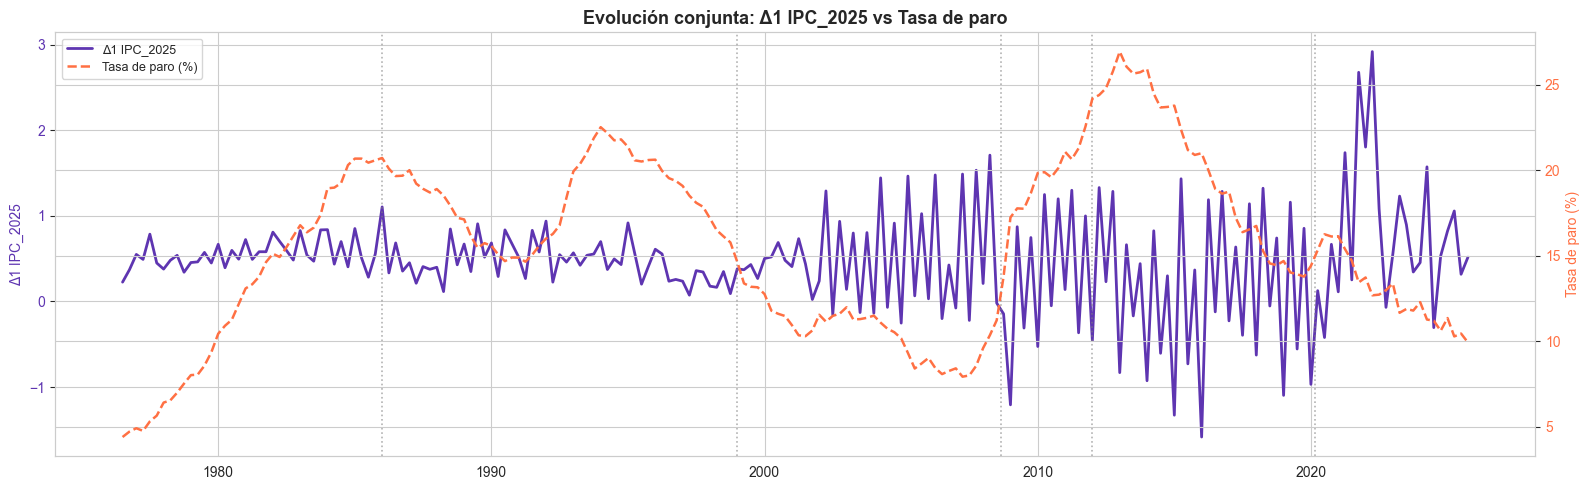

In [122]:
fig, ax1 = plt.subplots(figsize=(16, 5))
ax2 = ax1.twinx()

ax1.plot(main_s9.index, main_s9, color=COLOR_PRINCIPAL, lw=2,
         label=main_s9_label)
ax2.plot(parados_aligned.index, parados_aligned, color='#FF7043',
         lw=1.8, linestyle='--', label='Tasa de paro (%)')

ax1.set_ylabel(main_s9_label, color=COLOR_PRINCIPAL, fontsize=10)
ax2.set_ylabel('Tasa de paro (%)', color='#FF7043', fontsize=10)
ax1.tick_params(axis='y', labelcolor=COLOR_PRINCIPAL)
ax2.tick_params(axis='y', labelcolor='#FF7043')

for fecha_str, texto in EVENTOS.items():
    fecha_ev = pd.Timestamp(fecha_str)
    if main_s9.index.min() <= fecha_ev <= main_s9.index.max():
        ax1.axvline(fecha_ev, color='gray', linestyle=':', lw=1.2, alpha=0.6)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
ax1.set_title(f'Evolución conjunta: {main_s9_label} vs Tasa de paro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Análisis:

El gráfico de doble eje enfrenta la primera diferencia intertrimestral del `IPC_2025` (`Δ1`, en puntos de índice, eje izquierdo) con la tasa de paro (en porcentaje, eje derecho). El rasgo más visible de la serie `Δ1` no es su relación con el paro sino su heterocedasticidad: oscila con amplitud reducida y signo casi siempre positivo entre 1976 y 2000 (mayoritariamente entre 0 y 1 punto), y a partir de aproximadamente 2000 la amplitud se dispara, con oscilaciones que abarcan desde aproximadamente -1,5 hasta +2,9 puntos. Este cambio no responde a un aumento de la inflación real sino a la construcción de la variable: `Δ1` mide la variación en puntos de índice, de modo que su varianza crece mecánicamente con el nivel del índice, ya que un mismo porcentaje de inflación se traduce en más puntos cuando el índice es alto (post-2000) que cuando es bajo (años 70). El pico positivo máximo, de aproximadamente 2,9 puntos hacia 2022, corresponde al repunte inflacionista reciente, y los descensos más acusados, próximos a -1,5 puntos, se concentran en torno a 2009, 2015 y 2020.

La tasa de paro mantiene su perfil cíclico habitual, con máximos hacia 1985 (aproximadamente 21%), 1994 (aproximadamente 24%) y 2013 (aproximadamente 27%) y mínimos hacia 1979 y 2007 (aproximadamente 5% y 8%). No se aprecia co-movimiento contemporáneo claro entre ambas series: `Δ1` está dominada por oscilación de alta frecuencia mientras el paro describe un ciclo lento, de manera que cualquier relación entre ambas debe buscarse en la correlación rodante y en la estructura de adelanto-retraso, no en el gráfico de niveles.

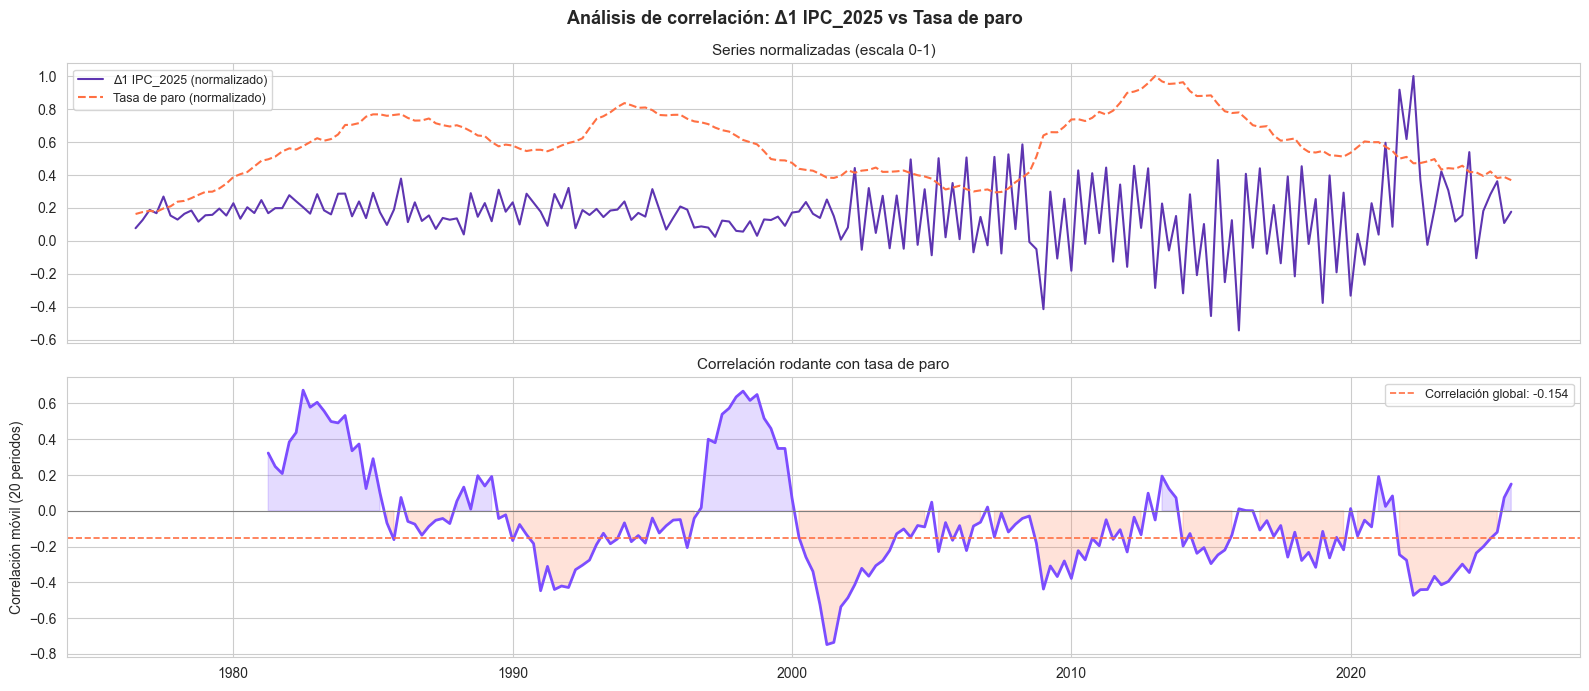

Correlación de Pearson global: -0.1540


In [123]:
ventana_corr = 20

df_cross = pd.DataFrame({'ipc': main_s9, 'parados': parados_aligned}).dropna()
rolling_corr = df_cross['ipc'].rolling(ventana_corr).corr(df_cross['parados'])
corr_global = df_cross['ipc'].corr(df_cross['parados'])

fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

axes[0].plot(df_cross.index, df_cross['ipc'] / df_cross['ipc'].max(),
             color=COLOR_PRINCIPAL, lw=1.5, label=f'{main_s9_label} (normalizado)')
axes[0].plot(df_cross.index, df_cross['parados'] / df_cross['parados'].max(),
             color='#FF7043', lw=1.5, linestyle='--', label='Tasa de paro (normalizado)')
axes[0].legend(fontsize=9)
axes[0].set_title('Series normalizadas (escala 0-1)', fontsize=11)

axes[1].plot(rolling_corr.index, rolling_corr, color='#7C4DFF', lw=2)
axes[1].axhline(0, color='gray', lw=0.8)
axes[1].axhline(corr_global, color='#FF7043', lw=1.2, linestyle='--',
                label=f'Correlación global: {corr_global:.3f}')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                      where=rolling_corr > 0, alpha=0.2, color='#7C4DFF')
axes[1].fill_between(rolling_corr.index, rolling_corr, 0,
                      where=rolling_corr < 0, alpha=0.2, color='#FF7043')
axes[1].set_ylabel(f'Correlación móvil ({ventana_corr} periodos)', fontsize=10)
axes[1].legend(fontsize=9)
axes[1].set_title('Correlación rodante con tasa de paro', fontsize=11)

fig.suptitle(f'Análisis de correlación: {main_s9_label} vs Tasa de paro', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Correlación de Pearson global: {corr_global:.4f}')

### Análisis:

La correlación de Pearson global entre `Δ1 IPC_2025` y la tasa de paro es -0,1540, débilmente negativa y aún más atenuada de lo que cabría esperar de la curva de Phillips, consecuencia de la inestabilidad de signo que domina la relación. La correlación rodante de 20 trimestres alterna entre tramos positivos y negativos sin signo persistente: registra máximos positivos próximos a +0,65 hacia 1983 y de nuevo hacia 1998-1999, y mínimos negativos de aproximadamente -0,45 hacia 1991 y de hasta -0,75 hacia 2001-2002, el valor más extremo de toda la muestra. Desde aproximadamente 2003 la correlación se mantiene en una banda estrecha mayoritariamente negativa o próxima a cero (entre aproximadamente -0,4 y +0,2), con un nuevo descenso hacia -0,5 en 2022-2023 y una recuperación hacia +0,15 al final del periodo.

Esta volatilidad del signo, con ciclos de aproximadamente 5 a 8 años, distingue a la inflación de las variables de participación laboral analizadas previamente, cuyo signo permanecía estable durante décadas. El co-movimiento positivo, con inflación y paro moviéndose en la misma dirección, corresponde a fases de estanflación o de ajuste conjunto, mientras que los tramos negativos reflejan la relación inversa de la Phillips clásica; la alternancia entre ambos hace que la correlación global apenas alcance -0,15. Como regresor de la tasa de paro, `Δ1` solo resulta interpretable en interacción con indicadores de régimen inflacionista o como variable de control del entorno macroeconómico, no como predictor directo de signo estable.

In [124]:
df_cross['decada'] = (df_cross.index.year // 10 * 10).astype(str) + 's'
paleta_decadas = ['#1565C0', '#00897B', '#FF7043', '#7C4DFF', '#FFC107', '#AD1457']

df_scatter = df_cross.reset_index().rename(columns={'index': 'fecha', df_cross.index.name or 'index': 'fecha'})
if 'fecha' not in df_scatter.columns:
    df_scatter.insert(0, 'fecha', df_cross.index.strftime('%Y-%m-%d'))
else:
    df_scatter['fecha'] = pd.to_datetime(df_scatter['fecha']).dt.strftime('%Y-%m-%d')

fig = px.scatter(
    df_scatter, x='ipc', y='parados',
    color='decada',
    hover_data=['fecha'],
    trendline='ols',
    trendline_scope='overall',
    color_discrete_sequence=paleta_decadas,
    title=f'Dispersión por década: {main_s9_label} vs Desempleo',
    labels={
        'ipc': main_s9_label,
        'parados': 'Tasa de paro (%)',
        'decada': 'Década', 'fecha': 'Fecha',
    },
)
fig.for_each_trace(lambda t: t.update(name='Tendencia global') if t.name == 'Overall Trendline' else None)
fig.update_traces(marker=dict(size=6, opacity=0.75))
fig.update_layout(height=520)
fig.show()

### Análisis:

El diagrama de dispersión por décadas confirma una recta de tendencia global (OLS) de pendiente negativa, que desciende desde aproximadamente 18% de paro en el extremo izquierdo (`Δ1` cercano a -1,5) hasta aproximadamente 12,5% en el derecho (`Δ1` cercano a +3), coherente con la correlación de -0,1540. La dispersión en torno a esa recta es muy elevada y las décadas se superponen ampliamente en la zona central (`Δ1` entre 0 y 1 punto, paro entre 10% y 22%), de modo que la pendiente captura una tendencia real pero económicamente débil.

La nube presenta dos formas de ordenación. Por un lado, una estratificación vertical de las décadas anteriores a 2000 según el nivel de paro: los años 70 se agrupan en la parte inferior, con paro entre aproximadamente 5% y 10%, mientras los años 80 ocupan la franja alta, entre 15% y 22%, ambos en un rango estrecho de `Δ1` mayoritariamente entre 0,2 y 0,9 puntos. Por otro, una dispersión horizontal creciente en las décadas recientes: los 2000s, 2010s y 2020s se despliegan sobre todo el eje de `Δ1`, y los valores extremos positivos, de aproximadamente +2,6 y +2,9 puntos con paro entre 12% y 14%, corresponden íntegramente a los 2020s, reflejo del repunte inflacionista reciente y de la heterocedasticidad de la variable. Esta combinación de superposición entre décadas, estratificación por paro en los periodos antiguos y ensanchamiento de escala en los recientes confirma que `Δ1` mantiene con la tasa de paro una relación estadísticamente significativa pero económicamente tenue, utilizable como variable de control del entorno macroeconómico pero insuficiente como predictor principal.

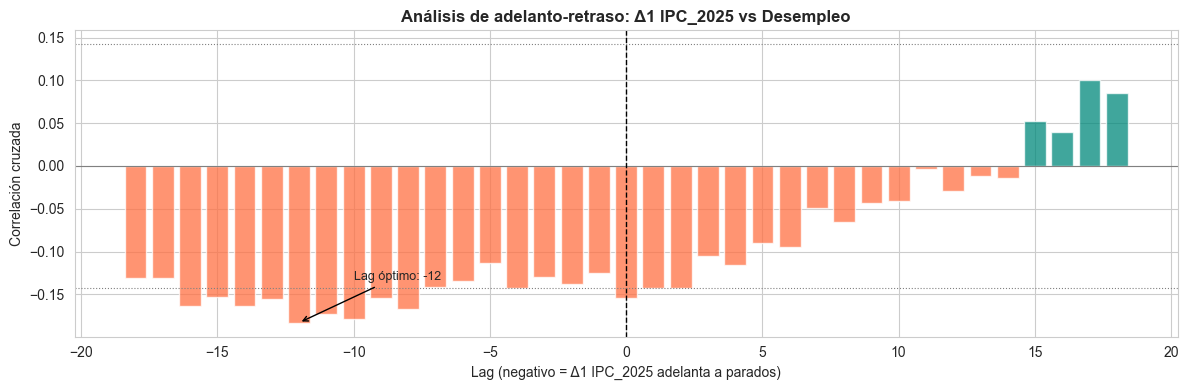

Lag con máxima correlación: -12 periodos
Correlación en ese lag: -0.1832
Banda de significancia (±2/√N): ±0.1421


In [125]:
max_lag = LAGS_ACF // 2

sa = (df_cross['ipc'] - df_cross['ipc'].mean()) / df_cross['ipc'].std()
sb = (df_cross['parados'] - df_cross['parados'].mean()) / df_cross['parados'].std()

lags_range = range(-max_lag, max_lag + 1)
ccf_vals = [sa.corr(sb.shift(-lag)) for lag in lags_range]

fig, ax = plt.subplots(figsize=(12, 4))
colors_ccf = ['#00897B' if v > 0 else '#FF7043' for v in ccf_vals]
ax.bar(list(lags_range), ccf_vals, color=colors_ccf, alpha=0.75)
ax.axhline(0, color='gray', lw=0.8)
ax.axvline(0, color='black', lw=1, linestyle='--')
sig = 2 / np.sqrt(len(df_cross))
ax.axhline(sig, color='gray', lw=0.8, linestyle=':')
ax.axhline(-sig, color='gray', lw=0.8, linestyle=':')

lag_max = list(lags_range)[np.argmax(np.abs(ccf_vals))]
ax.annotate(f'Lag óptimo: {lag_max}', xy=(lag_max, ccf_vals[lag_max + max_lag]),
            xytext=(lag_max + 2, ccf_vals[lag_max + max_lag] + 0.05),
            fontsize=9, arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel(f'Lag (negativo = {main_s9_label} adelanta a parados)', fontsize=10)
ax.set_ylabel('Correlación cruzada', fontsize=10)
ax.set_title(f'Análisis de adelanto-retraso: {main_s9_label} vs Desempleo', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Lag con máxima correlación: {lag_max} periodos')
print(f'Correlación en ese lag: {ccf_vals[lag_max + max_lag]:.4f}')
print(f'Banda de significancia (±2/√N): ±{sig:.4f}')

### Análisis:

El análisis de correlación cruzada entre `Δ1 IPC_2025` y la tasa de paro arroja una señal débil en todo el rango de adelantos. La banda de significancia al 95%, calculada como ±2/√N, se sitúa en ±0,1421. El lag óptimo es -12 trimestres, con una correlación de -0,1832, el único valor que supera con holgura la banda, e indica que la variación intertrimestral del IPC adelanta a la tasa de paro en aproximadamente tres años con signo negativo (mayor inflación intertrimestral asociada a menor desempleo doce trimestres después), consistente con una curva de Phillips muy retardada.

El perfil es negativo en prácticamente todo el rango de lags, desde -18 hasta aproximadamente +14, pero con magnitudes reducidas: la mayoría de los coeficientes oscila entre -0,10 y -0,15 y solo el entorno de los lags -8 a -16 supera de forma sostenida la banda de significancia. La correlación contemporánea (lag 0) y los lags cortos (-1 a -4) se sitúan en torno a -0,15, justo en el límite de significancia. El tramo de lags positivos elevados, en que el paro adelantaría a `Δ1`, se vuelve ligeramente positivo pero no supera la banda, con valores máximos próximos a +0,10 en los lags +17 y +18, por debajo del umbral de ±0,1421, por lo que no admite una lectura de causalidad inversa.

En conjunto, `Δ1` es un regresor débil de la tasa de paro: el máximo de correlación se localiza en un horizonte de doce trimestres, demasiado largo para la predicción a corto plazo, mientras que en los lags cortos operativamente útiles la señal apenas alcanza el umbral de significancia. En el pipeline puede incluirse con varios retardos dejando la selección al algoritmo, pero no debe esperarse de ella una capacidad predictiva de primer orden sobre la tasa de paro.